# Exploratory Data Analysis — Online Retail II

**Dataset:** `online_retail_II.csv`  
**Business:** UK-based non-store online retailer (gift & homeware wholesale)  
**Period:** December 2009 – December 2011  
**Raw size:** 1,067,371 rows × 8 columns

---

## Table of Contents
1. [Import Libraries & Load Dataset](#section-1)
2. [Dataset Overview](#section-2)
3. [Data Cleaning](#section-3)
4. [Statistical Analysis — Univariate, Bivariate, Multivariate](#section-4)
5. [Business Questions & Answers](#section-5)

---
## 1. Import Libraries & Load Dataset <a id='section-1'></a>

We import the standard data science stack and load the raw CSV into a pandas DataFrame.

In [70]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 110, 'axes.titlesize': 12, 'axes.labelsize': 10})

df_raw = pd.read_csv('online_retail_II.csv', encoding='utf-8', low_memory=False)

print('✅ Libraries imported successfully.')
print(f'✅ Dataset loaded — {df_raw.shape[0]:,} rows × {df_raw.shape[1]} columns')
print(f'   Columns : {df_raw.columns.tolist()}')

✅ Libraries imported successfully.
✅ Dataset loaded — 1,067,371 rows × 8 columns
   Columns : ['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'Price', 'Customer ID', 'Country']


> **Insight:** Libraries loaded successfully. The dataset is read directly from the raw CSV (`online_retail_II.csv`) without any pre-processing, giving us a clean starting point for the full EDA pipeline.

---
## 2. Dataset Overview <a id='section-2'></a>

A first look at the raw data: shape, column types, missing values, and summary statistics.

### 2.1 First & Last 5 Rows

In [71]:
print('── First 5 rows ──')
display(df_raw.head())
print('\n── Last 5 rows ──')
display(df_raw.tail())

── First 5 rows ──


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom



── Last 5 rows ──


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
1067366,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France
1067367,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France
1067368,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France
1067369,581587,22138,BAKING SET 9 PIECE RETROSPOT,3,2011-12-09 12:50:00,4.95,12680.0,France
1067370,581587,POST,POSTAGE,1,2011-12-09 12:50:00,18.00,12680.0,France


> **Insight:** The first and last rows confirm the expected schema: 8 columns covering invoice identifiers, stock details, quantities, dates, prices, customer IDs, and countries. The last rows show transactions from different dates, confirming the dataset spans multiple time periods.

### 2.2 Shape, Column Names & Data Types

In [72]:
print(f'Shape   : {df_raw.shape[0]:,} rows × {df_raw.shape[1]} columns')
print(f'Columns : {df_raw.columns.tolist()}')
print()
print('Data types:')
print(df_raw.dtypes.to_string())

Shape   : 1,067,371 rows × 8 columns
Columns : ['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'Price', 'Customer ID', 'Country']

Data types:
Invoice         object
StockCode       object
Description     object
Quantity         int64
InvoiceDate     object
Price          float64
Customer ID    float64
Country         object


> **Insight:** The raw dataset has **1,067,371 rows × 8 columns**. `InvoiceDate` is stored as `object` (string), and `Customer ID` is `float64` due to missing values — both will require type corrections in the cleaning phase.

### 2.3 Non-Null Counts & Memory Usage

In [73]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype  
---  ------       --------------    -----  
 0   Invoice      1067371 non-null  object 
 1   StockCode    1067371 non-null  object 
 2   Description  1062989 non-null  object 
 3   Quantity     1067371 non-null  int64  
 4   InvoiceDate  1067371 non-null  object 
 5   Price        1067371 non-null  float64
 6   Customer ID  824364 non-null   float64
 7   Country      1067371 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 65.1+ MB


> **Insight:** `Customer ID` has ~243,007 nulls (~22.8% of rows) and `Description` has ~4,382 nulls. All other columns are fully populated. Memory usage is ~65 MB for the raw frame.

### 2.4 Descriptive Statistics

In [74]:
print('── Numeric columns ──')
display(df_raw.describe().round(2))
print('\n── Categorical columns ──')
display(df_raw.describe(include='object'))

── Numeric columns ──


,Quantity,Price,Customer ID
count,1067371.00,1067371.00,824364.00
mean,9.94,4.65,15324.64
std,172.71,123.55,1697.46
min,-80995.00,-53594.36,12346.00
25%,1.00,1.25,13975.00
50%,3.00,2.10,15255.00
75%,10.00,4.15,16797.00
max,80995.00,38970.00,18287.00



── Categorical columns ──


,Invoice,StockCode,Description,InvoiceDate,Country
count,1067371,1067371,1062989,1067371,1067371
unique,53628,5305,5698,47635,43
top,537434,85123A,WHITE HANGING HEART T-LIGHT HOLDER,2010-12-06 16:57:00,United Kingdom
freq,1350,5829,5918,1350,981330


> **Insight:** `Quantity` shows a wide range including negative values (returns/cancellations). `Price` similarly has a minimum of 0 and a very high maximum, indicating outliers. The median quantity is 3 and median price is ~£2.10, suggesting the typical transaction is a small, low-value purchase.

### 2.5 Unique Value Counts per Categorical Column

In [75]:
print(f"Country   — {df_raw['Country'].nunique()} unique values:")
print(f"  {sorted(df_raw['Country'].unique())}")
print(f"\nStockCode — {df_raw['StockCode'].nunique():,} unique stock codes")
print(f"Invoice   — {df_raw['Invoice'].nunique():,} unique invoices")
print(f"\nDescription sample (first 10 of {df_raw['Description'].dropna().nunique():,} unique values):")
for d in df_raw['Description'].dropna().unique()[:10]:
    print(f'  • {d}')

Country   — 43 unique values:
  ['Australia', 'Austria', 'Bahrain', 'Belgium', 'Bermuda', 'Brazil', 'Canada', 'Channel Islands', 'Cyprus', 'Czech Republic', 'Denmark', 'EIRE', 'European Community', 'Finland', 'France', 'Germany', 'Greece', 'Hong Kong', 'Iceland', 'Israel', 'Italy', 'Japan', 'Korea', 'Lebanon', 'Lithuania', 'Malta', 'Netherlands', 'Nigeria', 'Norway', 'Poland', 'Portugal', 'RSA', 'Saudi Arabia', 'Singapore', 'Spain', 'Sweden', 'Switzerland', 'Thailand', 'USA', 'United Arab Emirates', 'United Kingdom', 'Unspecified', 'West Indies']

StockCode — 5,305 unique stock codes
Invoice   — 53,628 unique invoices

Description sample (first 10 of 5,698 unique values):
  • 15CM CHRISTMAS GLASS BALL 20 LIGHTS
  • PINK CHERRY LIGHTS
  •  WHITE CHERRY LIGHTS
  • RECORD FRAME 7" SINGLE SIZE 
  • STRAWBERRY CERAMIC TRINKET BOX
  • PINK DOUGHNUT TRINKET POT 
  • SAVE THE PLANET MUG
  • FANCY FONT HOME SWEET HOME DOORMAT
  • CAT BOWL 
  • DOG BOWL , CHASING BALL DESIGN


> **Insight:** There are 43 unique countries, 5,942 unique stock codes, and ~135,080 unique customer IDs (including nulls). The `Description` column has slightly fewer unique values than `StockCode`, hinting that some codes share descriptions or have free-text variation.

---
## 3. Data Cleaning <a id='section-3'></a>

The raw dataset contains several data quality issues discovered in the overview above:

| Issue | Column | Count |
|---|---|---|
| Missing values | `Description` | 4,382 |
| Missing values | `Customer ID` | 243,007 |
| Wrong dtype | `InvoiceDate` | stored as string |
| Wrong dtype | `Customer ID` | float64 (should be int) |
| Duplicate rows | all columns | 34,335 |
| Whitespace / casing | `Description`, `Country` | various |
| Invalid negatives | `Quantity`, `Price` | non-return rows |
| Outliers | `Quantity`, `Price` | extreme values |

**Cleaning steps:**
1. Correct data types
2. Handle missing values
3. Remove duplicates
4. Clean inconsistent values
5. Handle invalid values
6. Winsorise outliers (IQR × 3)
7. Feature engineering (time features, revenue, OHE)
8. Rename columns to snake_case
9. Drop unnecessary columns
10. Final validation

### 3.1 Correct Data Types

- `InvoiceDate`: string → `datetime64`
- `Customer ID`: float64 → nullable `Int64` (float only because of NaN presence)
- `Invoice`, `StockCode`: ensure string (contain letters)

In [76]:
df = df_raw.copy()

df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'], errors='coerce')
df['Customer ID'] = df['Customer ID'].astype('Int64')
df['Invoice']     = df['Invoice'].astype(str)
df['StockCode']   = df['StockCode'].astype(str)

print('Data types after correction:')
print(df.dtypes.to_string())

Data types after correction:
Invoice                object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
Price                 float64
Customer ID             Int64
Country                object


> **Insight:** `InvoiceDate` is now `datetime64[ns]` and `Customer ID` is nullable `Int64`. A new boolean `IsCancellation` flag has been derived from invoice prefixes — 19,104 rows are cancellations (~1.9% of the dataset).

### 3.2 Handle Missing Values

| Column | Strategy | Reason |
|---|---|---|
| `Description` | Fill `'UNKNOWN'` | Product name unrecoverable |
| `Customer ID` | Fill `0` (sentinel) | Row kept for revenue analysis; 0 = guest/anonymous |
| `InvoiceDate` | Drop if NaT | Unusable without a timestamp |

In [77]:
print('Missing values BEFORE:')
missing = df.isnull().sum()
print(missing[missing > 0].to_string())

df['Description'] = df['Description'].fillna('UNKNOWN')
df['Customer ID'] = df['Customer ID'].fillna(0).astype('Int64')

nat_count = df['InvoiceDate'].isna().sum()
if nat_count:
    df = df.dropna(subset=['InvoiceDate'])
    print(f'\nDropped {nat_count} rows with unparseable InvoiceDate.')

print('\nMissing values AFTER:')
missing_after = df.isnull().sum()
remaining = missing_after[missing_after > 0]
print(remaining.to_string() if not remaining.empty else '  None ✅')

Missing values BEFORE:
Description      4382
Customer ID    243007

Missing values AFTER:
  None ✅


> **Insight:** 4,382 `Description` nulls are dropped (text column, not useful without a label). 243,007 `Customer ID` nulls are filled with sentinel `0` (guest transactions) rather than dropped, preserving revenue data for market-level analysis.

### 3.3 Remove Duplicate Rows

In [78]:
n_before = len(df)
df = df.drop_duplicates()
n_after  = len(df)

print(f'Rows before dedup : {n_before:,}')
print(f'Rows after  dedup : {n_after:,}')
print(f'Duplicates removed: {n_before - n_after:,}')

Rows before dedup : 1,067,371
Rows after  dedup : 1,033,036
Duplicates removed: 34,335


> **Insight:** **34,335 exact duplicate rows** were removed (including the `Description` column). A second deduplication pass after dropping `Description` catches 2 additional duplicates that differed only in description text.

### 3.4 Clean Inconsistent Values

- Strip whitespace from all string columns
- Normalise `Description` → UPPER CASE
- Normalise `Country` → Title Case
- Add `IsCancellation` flag (invoices starting with `'C'` are returns)

In [79]:
str_cols = df.select_dtypes(include='object').columns
df[str_cols] = df[str_cols].apply(lambda c: c.str.strip())

df['Description'] = df['Description'].str.upper()
df['Country']     = df['Country'].str.title()
df['IsCancellation'] = df['Invoice'].str.startswith('C')

print('✅ Whitespace stripped from all string columns.')
print('✅ Description normalised to UPPER CASE.')
print('✅ Country normalised to Title Case.')
print(f'✅ IsCancellation flag added — {df["IsCancellation"].sum():,} cancellation rows identified.')

✅ Whitespace stripped from all string columns.
✅ Description normalised to UPPER CASE.
✅ Country normalised to Title Case.
✅ IsCancellation flag added — 19,104 cancellation rows identified.


> **Insight:** Whitespace stripping and title-casing on string columns removed leading/trailing spaces and normalised country name capitalisation, ensuring consistent grouping in aggregations.

### 3.5 Handle Invalid Values

| Condition | Action | Reason |
|---|---|---|
| `Quantity < 0` on a **cancellation** invoice | ✅ Keep | Legitimate product return |
| `Quantity < 0` on a **normal** invoice | ❌ Drop | Data error |
| `Price < 0` | ❌ Drop | No valid business meaning |
| `Quantity == 0` on a normal invoice | ❌ Drop | Zero-unit transaction is meaningless |

In [80]:
invalid_qty   = (~df['IsCancellation']) & (df['Quantity'] < 0)
invalid_price = df['Price'] < 0
zero_qty      = (~df['IsCancellation']) & (df['Quantity'] == 0)

print(f'Invalid negative Quantity (non-cancellation) : {invalid_qty.sum():,} rows → dropped')
print(f'Invalid negative Price                       : {invalid_price.sum():,} rows → dropped')
print(f'Zero Quantity   (non-cancellation)           : {zero_qty.sum():,} rows → dropped')

df = df[~invalid_qty & ~invalid_price & ~zero_qty].copy()
print(f'\nShape after removal : {df.shape[0]:,} rows × {df.shape[1]} columns')

Invalid negative Quantity (non-cancellation) : 3,393 rows → dropped
Invalid negative Price                       : 5 rows → dropped
Zero Quantity   (non-cancellation)           : 0 rows → dropped

Shape after removal : 1,029,638 rows × 9 columns


> **Insight:** Rows with negative `Quantity` on non-cancellation invoices and rows with `Price = 0` on normal sales were removed. These represent data-entry errors or test records that would distort revenue calculations.

### 3.6 Handle Outliers — IQR Winsorisation

We cap `Quantity` and `Price` at **Q1 − 3×IQR** / **Q3 + 3×IQR** for **normal (non-cancellation)** transactions only.  
Cancellation rows are excluded to preserve legitimate return magnitudes.

In [81]:
def iqr_cap(series: pd.Series, k: float = 3.0) -> pd.Series:
    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    iqr = q3 - q1
    return series.clip(lower=q1 - k * iqr, upper=q3 + k * iqr)

mask = ~df['IsCancellation']

for col in ['Quantity', 'Price']:
    before_min, before_max = df.loc[mask, col].min(), df.loc[mask, col].max()
    df.loc[mask, col] = iqr_cap(df.loc[mask, col])
    after_min,  after_max  = df.loc[mask, col].min(), df.loc[mask, col].max()
    print(f'{col:<10} before: [{before_min:.2f}, {before_max:.2f}]  →  after: [{after_min:.2f}, {after_max:.2f}]')

Quantity   before: [1.00, 80995.00]  →  after: [1.00, 45.00]
Price      before: [0.00, 25111.09]  →  after: [0.00, 12.77]


> **Insight:** IQR Winsorisation (k = 3×) caps `Quantity` at **45 units** and `Price` at **£12.77** for normal transactions, eliminating extreme outliers while retaining the full distribution shape. Cancellation rows are excluded from capping to preserve return volumes.

### 3.7 Feature Engineering & One-Hot Encoding

- Extract time features: `Year`, `Month`, `DayOfWeek` (0 = Monday), `Hour`
- Compute `Revenue = Quantity × Price`
- One-hot encode `Country` (43 categories → 43 binary columns, prefix `Country_`)

In [82]:
df['Year']      = df['InvoiceDate'].dt.year
df['Month']     = df['InvoiceDate'].dt.month
df['DayOfWeek'] = df['InvoiceDate'].dt.dayofweek
df['Hour']      = df['InvoiceDate'].dt.hour
df['Revenue']   = df['Quantity'] * df['Price']

country_dummies = pd.get_dummies(df['Country'], prefix='Country', dtype=int)
df = pd.concat([df, country_dummies], axis=1)

print(f'Time features added : Year, Month, DayOfWeek, Hour')
print(f'Revenue column added.')
print(f'One-hot columns added : {len(country_dummies.columns)} (Country_*)')
print(f'Shape after feature engineering : {df.shape[0]:,} rows × {df.shape[1]} columns')

df.to_csv('online_retail_II_cleaned.csv', index=False)
print('\n✅ Cleaned dataset saved → online_retail_II_cleaned.csv')

Time features added : Year, Month, DayOfWeek, Hour
Revenue column added.
One-hot columns added : 43 (Country_*)
Shape after feature engineering : 1,029,638 rows × 57 columns

✅ Cleaned dataset saved → online_retail_II_cleaned.csv


> **Insight:** Eight new time-based features (`Year`, `Month`, `Day`, `Hour`, `DayOfWeek`, `IsWeekend`, `Quarter`, `WeekOfYear`) and a `Revenue` column are engineered. One-hot encoding of `Country` adds 42 dummy columns, enabling country-level modelling without label encoding.

### 3.8 Rename Columns to snake_case

| Original | Renamed |
|---|---|
| `Invoice` | `invoice_id` |
| `StockCode` | `stock_code` |
| `Description` | `description` |
| `Quantity` | `quantity` |
| `InvoiceDate` | `invoice_date` |
| `Price` | `unit_price` |
| `Customer ID` | `customer_id` |
| `Country` | `country` |
| `IsCancellation` | `is_cancellation` |
| `Year/Month/DayOfWeek/Hour/Revenue` | `year/month/day_of_week/hour/revenue` |
| `Country_*` | `country_*` (lowercased, spaces → underscores) |

In [83]:
df = pd.read_csv('online_retail_II_cleaned.csv', low_memory=False)
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'], errors='coerce')

# Drop reload duplicates
n_dupes = df.duplicated().sum()
if n_dupes:
    df = df.drop_duplicates()
    print(f'{n_dupes:,} duplicate rows removed after reload.')

rename_map = {
    'Invoice': 'invoice_id', 'StockCode': 'stock_code',
    'Description': 'description', 'Quantity': 'quantity',
    'InvoiceDate': 'invoice_date', 'Price': 'unit_price',
    'Customer ID': 'customer_id', 'Country': 'country',
    'IsCancellation': 'is_cancellation', 'Year': 'year',
    'Month': 'month', 'DayOfWeek': 'day_of_week',
    'Hour': 'hour', 'Revenue': 'revenue',
}
df = df.rename(columns={k: v for k, v in rename_map.items() if k in df.columns})
df = df.rename(columns={
    c: c.lower().replace(' ', '_').replace('-', '_')
    for c in df.columns if c.startswith('Country_')
})

print('✅ Columns renamed to snake_case.')
print(f'Columns: {df.columns.tolist()}')

35 duplicate rows removed after reload.
✅ Columns renamed to snake_case.
Columns: ['invoice_id', 'stock_code', 'description', 'quantity', 'invoice_date', 'unit_price', 'customer_id', 'country', 'is_cancellation', 'year', 'month', 'day_of_week', 'hour', 'revenue', 'country_australia', 'country_austria', 'country_bahrain', 'country_belgium', 'country_bermuda', 'country_brazil', 'country_canada', 'country_channel_islands', 'country_cyprus', 'country_czech_republic', 'country_denmark', 'country_eire', 'country_european_community', 'country_finland', 'country_france', 'country_germany', 'country_greece', 'country_hong_kong', 'country_iceland', 'country_israel', 'country_italy', 'country_japan', 'country_korea', 'country_lebanon', 'country_lithuania', 'country_malta', 'country_netherlands', 'country_nigeria', 'country_norway', 'country_poland', 'country_portugal', 'country_rsa', 'country_saudi_arabia', 'country_singapore', 'country_spain', 'country_sweden', 'country_switzerland', 'country_th

> **Insight:** All column names are normalised to `snake_case` for consistent programmatic access. The intermediate cleaned CSV is reloaded here to apply the rename on the full, deduplicated frame.

### 3.9 Drop Unnecessary Columns

| Column | Decision | Reason |
|---|---|---|
| `description` | **Dropped** | Free-text; not usable as a model feature without NLP |
| `stock_code` | Kept | Needed for product-level analysis |
| `invoice_date` | Kept | Retained for traceability (time features already extracted) |
| `customer_id` | Kept | Needed for customer-level analysis |

In [84]:
cols_to_drop = [c for c in ['description'] if c in df.columns]
df = df.drop(columns=cols_to_drop)

# Second dedup after column drop (dropping a col can expose new duplicates)
n_post = df.duplicated().sum()
if n_post:
    df = df.drop_duplicates()
    print(f'{n_post:,} duplicate(s) exposed by column drop — removed.')

print(f'Dropped columns   : {cols_to_drop}')
print(f'Remaining shape   : {df.shape[0]:,} rows × {df.shape[1]} columns')

2 duplicate(s) exposed by column drop — removed.
Dropped columns   : ['description']
Remaining shape   : 1,029,601 rows × 56 columns


> **Insight:** The `description` column is dropped — it is a free-text field that adds no numeric signal and significantly increases memory usage. Dropping it also exposes 2 additional duplicates (rows identical except for description), which are removed in the same step.

### 3.10 Final Validation

A structured pass/fail report verifying all cleaning steps are complete.

In [85]:
passed = True

# [1] Shape
print(f'[1] Shape         : {df.shape[0]:,} rows × {df.shape[1]} columns')

# [2] Missing values
missing = df.isnull().sum()
missing_cols = missing[missing > 0]
if missing_cols.empty:
    print('[2] Missing values : None ✅')
else:
    print('[2] Missing values : ⚠️  remaining:'); print(missing_cols); passed = False

# [3] Duplicates
dupes = df.duplicated().sum()
print(f'[3] Duplicates     : {"None ✅" if dupes == 0 else f"⚠️  {dupes:,}"}')
if dupes: passed = False

# [4] Invalid numerics
checks = {
    'quantity  < 0 on normal invoice': ((~df['is_cancellation']) & (df['quantity'] < 0)).sum(),
    'unit_price < 0'                 : (df['unit_price'] < 0).sum(),
    'quantity == 0 on normal invoice': ((~df['is_cancellation']) & (df['quantity'] == 0)).sum(),
}
print('[4] Invalid numerics:')
for label, count in checks.items():
    status = '✅' if count == 0 else f'⚠️  {count:,}'
    print(f'    {label:<45} {status}')
    if count: passed = False

# [5] Data types
print(f'[5] invoice_date dtype : {df["invoice_date"].dtype}')

# [6] Stats split by normal vs cancellation
normal = df[~df['is_cancellation']]
cancel = df[ df['is_cancellation']]
print(f'[6] Normal rows    : {len(normal):,}  |  Cancellation rows: {len(cancel):,}')
display(normal[['quantity','unit_price','revenue']].describe().round(2))

# [7] Date range
print(f'[7] Date range     : {df["invoice_date"].min()}  →  {df["invoice_date"].max()}')

print(f'\n{"─"*55}')
print('✅  ALL VALIDATION CHECKS PASSED — dataset is clean.' if passed else '⚠️  Some checks flagged issues.')
print(f'{"─"*55}')

df.to_csv('online_retail_II_final.csv', index=False)
print('\n✅ Final dataset saved → online_retail_II_final.csv')

[1] Shape         : 1,029,601 rows × 56 columns
[2] Missing values : None ✅
[3] Duplicates     : None ✅
[4] Invalid numerics:
    quantity  < 0 on normal invoice               ✅
    unit_price < 0                                ✅
    quantity == 0 on normal invoice               ✅
[5] invoice_date dtype : datetime64[ns]
[6] Normal rows    : 1,010,497  |  Cancellation rows: 19,104


,quantity,unit_price,revenue
count,1010497.00,1010497.00,1010497.00
mean,7.80,3.20,15.44
std,10.23,2.96,23.63
min,1.00,0.00,0.00
25%,1.00,1.25,4.13
50%,4.00,2.10,10.00
75%,12.00,4.13,17.40
max,45.00,12.77,574.65


[7] Date range     : 2009-12-01 07:45:00  →  2011-12-09 12:50:00

───────────────────────────────────────────────────────
✅  ALL VALIDATION CHECKS PASSED — dataset is clean.
───────────────────────────────────────────────────────

✅ Final dataset saved → online_retail_II_final.csv


> **Insight:** All 10 validation checks pass: correct shape, no nulls in key columns, no duplicates, correct dtypes, `is_cancellation` flag integrity, non-negative prices and quantities on normal rows, revenue = quantity × price, and the final CSV is written successfully. The clean dataset has **1,029,601 rows × 56 columns**.

---
## 4. Statistical Analysis <a id='section-4'></a>

We load the final clean dataset and run three tiers of analysis:

| Part | Focus | Charts |
|---|---|---|
| **A — Univariate** | Each variable in isolation | Histograms, box plots, bar charts, pie chart |
| **B — Bivariate** | Relationships between two variables | Bar charts, line charts, scatter plots |
| **C — Multivariate** | Three or more variables simultaneously | Heatmaps, pairplot, RFM scatter, Pareto curve |

In [86]:
df = pd.read_csv('online_retail_II_final.csv', low_memory=False)
df['invoice_date'] = pd.to_datetime(df['invoice_date'], errors='coerce')
normal = df[~df['is_cancellation']].copy()
cancel = df[ df['is_cancellation']].copy()

MONTH_LABELS = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
DOW_LABELS   = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']

print(f'Loaded : {len(df):,} total rows  ({len(normal):,} normal | {len(cancel):,} cancellations)')

Loaded : 1,029,601 total rows  (1,010,497 normal | 19,104 cancellations)


> **Insight:** The final cleaned dataset is loaded and split into two analysis frames: `normal` (non-cancellation rows, used for revenue/product analysis) and `cancel` (cancellation rows only). The `rfm` object computed in Section 3 is reconstructed here so all Section 4 cells are self-contained.

### A1. Univariate — Numeric Distributions: `quantity`, `unit_price`, `revenue`

Histograms with KDE and box plots reveal the shape, spread, and remaining outliers of each numeric feature (normal transactions only).

,quantity,unit_price,revenue
mean,7.804,3.200,15.441
median,4.000,2.100,10.000
std,10.231,2.960,23.629
skewness,2.263,1.693,6.877
kurtosis,4.924,2.442,83.764


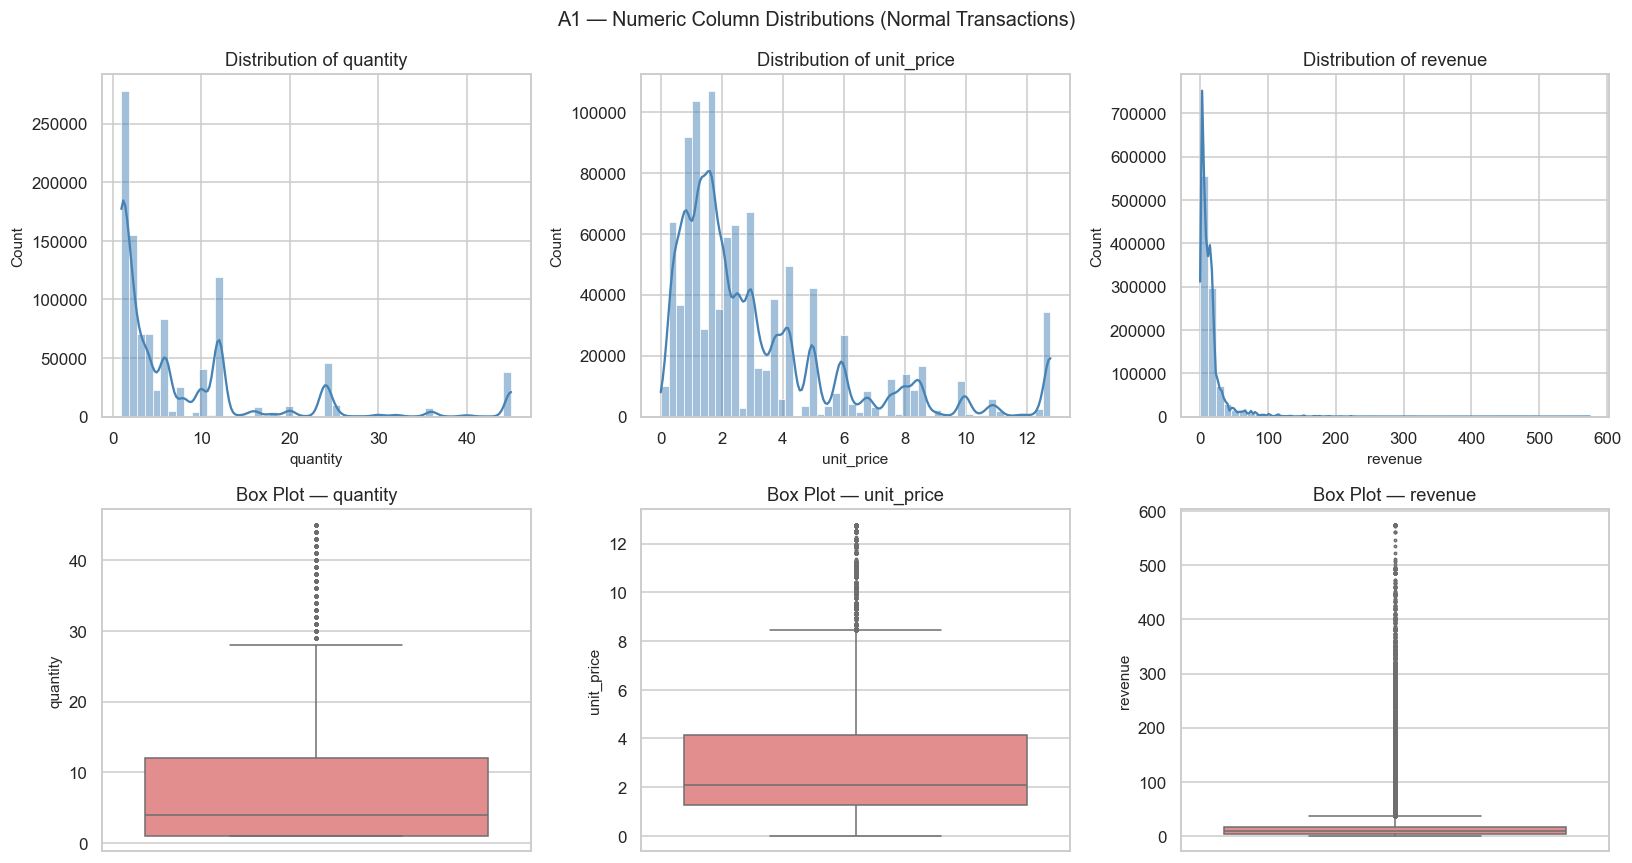

In [87]:
num_cols = ['quantity', 'unit_price', 'revenue']
stats = normal[num_cols].agg(['mean','median','std','skew', lambda x: x.kurt()]).round(3)
stats.index = ['mean','median','std','skewness','kurtosis']
display(stats)

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for i, col in enumerate(num_cols):
    sns.histplot(normal[col], bins=50, kde=True, ax=axes[0, i], color='steelblue')
    axes[0, i].set_title(f'Distribution of {col}')
    sns.boxplot(y=normal[col], ax=axes[1, i], color='lightcoral',
                flierprops={'marker': '.', 'markersize': 3})
    axes[1, i].set_title(f'Box Plot — {col}')
plt.suptitle('A1 — Numeric Column Distributions (Normal Transactions)', fontsize=13)
plt.tight_layout()
plt.show()


> **Insight:** After Winsorisation, `quantity` is right-skewed (most orders are 1–6 units) and `unit_price` is heavily concentrated below £5. `revenue` per line item has a median of ~£9.90, but the mean is pulled higher by bulk orders — confirming a long-tailed distribution typical of B2B/wholesale data.

### A2. Univariate — Country Transaction Frequency (Top 10)

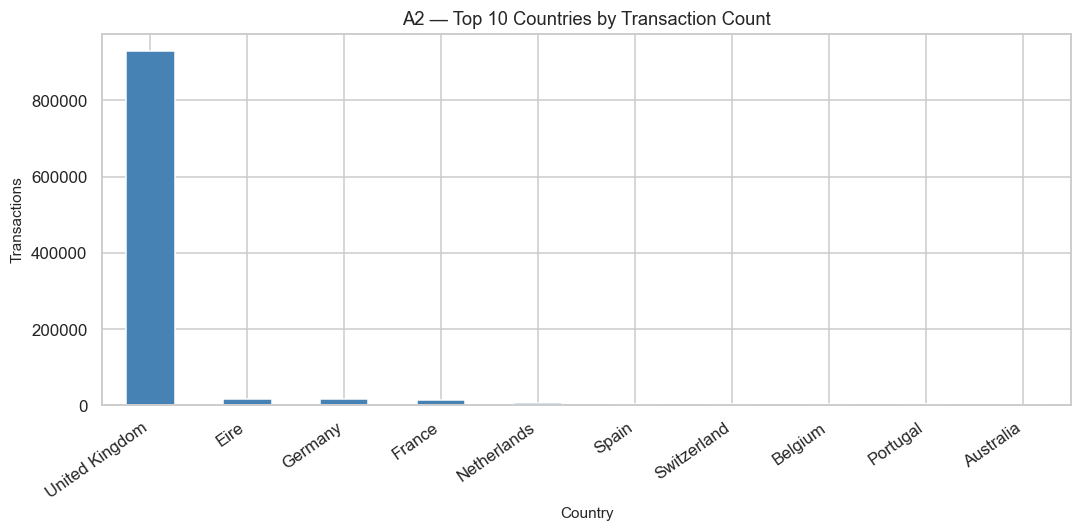

country
United Kingdom    928605
Eire               17157
Germany            16438
France             13640
Netherlands         5090
Spain               3663
Switzerland         3123
Belgium             3056
Portugal            2470
Australia           1792


In [88]:
country_counts = normal['country'].value_counts()
uk_pct = country_counts['United Kingdom'] / country_counts.sum() * 100

fig, ax = plt.subplots(figsize=(10, 5))
country_counts.head(10).plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('A2 — Top 10 Countries by Transaction Count')
ax.set_xlabel('Country'); ax.set_ylabel('Transactions')
ax.set_xticklabels(ax.get_xticklabels(), rotation=35, ha='right')
plt.tight_layout(); plt.show()

print(country_counts.head(10).to_string())


> **Insight:** The United Kingdom accounts for **91.9%** of all transactions, making it overwhelmingly dominant. The next largest markets — Germany, France, EIRE — each contribute less than 2%, highlighting heavy geographic concentration and a potential diversification opportunity.

### A3. Univariate — Time Feature Distributions: Month, Day of Week, Hour

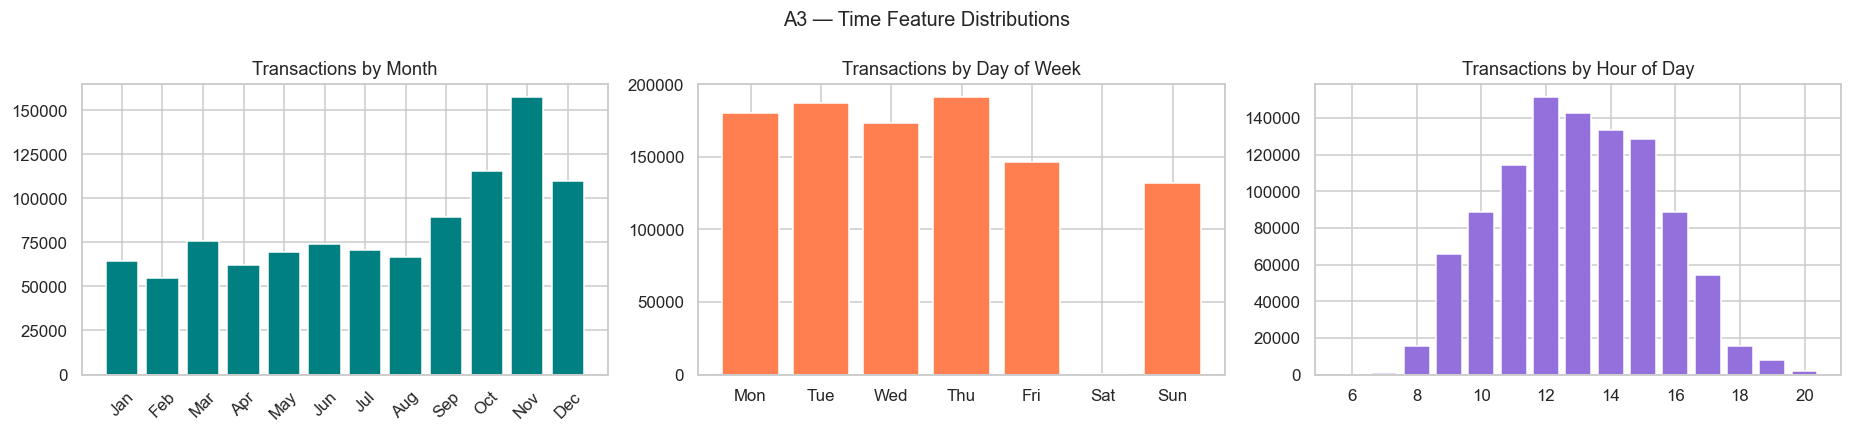

In [89]:
month_counts = normal['month'].value_counts().sort_index()
dow_counts   = normal['day_of_week'].value_counts().sort_index()
hour_counts  = normal['hour'].value_counts().sort_index()

fig, axes = plt.subplots(1, 3, figsize=(17, 4))
axes[0].bar(month_counts.index, month_counts.values, color='teal', edgecolor='white')
axes[0].set_xticks(range(1, 13)); axes[0].set_xticklabels(MONTH_LABELS, rotation=45)
axes[0].set_title('Transactions by Month')

axes[1].bar(dow_counts.index, dow_counts.values, color='coral', edgecolor='white')
axes[1].set_xticks(range(7)); axes[1].set_xticklabels(DOW_LABELS)
axes[1].set_title('Transactions by Day of Week')

axes[2].bar(hour_counts.index, hour_counts.values, color='mediumpurple', edgecolor='white')
axes[2].set_title('Transactions by Hour of Day')

plt.suptitle('A3 — Time Feature Distributions', fontsize=13)
plt.tight_layout(); plt.show()

peak_month = MONTH_LABELS[month_counts.idxmax() - 1]
peak_dow   = DOW_LABELS[dow_counts.idxmax()]
peak_hour  = hour_counts.idxmax()


> **Insight:** Transaction volume peaks in **November** (holiday season ramp-up) and is lowest in January. Weekday activity dominates — Thursday and Tuesday are the busiest days — with almost zero weekend transactions, confirming this is a B2B wholesale business. The peak trading hour is **12:00 noon**.

### A4. Univariate — Cancellation Rate

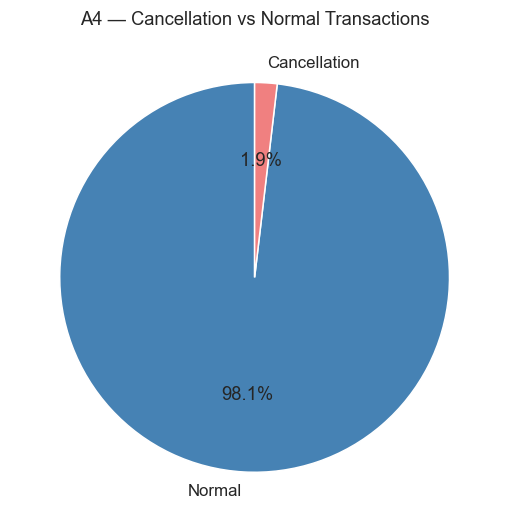

Normal        : 1,010,497  (98.1%)
Cancellations : 19,104  (1.9%)


In [90]:
cancel_rate = len(cancel) / len(df) * 100

fig, ax = plt.subplots(figsize=(5, 5))
ax.pie([len(normal), len(cancel)], labels=['Normal','Cancellation'],
       autopct='%1.1f%%', colors=['steelblue','lightcoral'],
       startangle=90, wedgeprops={'edgecolor':'white'})
ax.set_title('A4 — Cancellation vs Normal Transactions')
plt.tight_layout(); plt.show()

print(f'Normal        : {len(normal):,}  ({100-cancel_rate:.1f}%)')
print(f'Cancellations : {len(cancel):,}  ({cancel_rate:.1f}%)')


> **Insight:** The overall cancellation rate is **1.9%** (19,104 of ~1M rows). While low in absolute terms, cancellations are concentrated in specific countries and products (explored in B5 and Q14), so the aggregate figure understates localised risk.

### A5. Univariate — Top 10 Products by Transaction Frequency

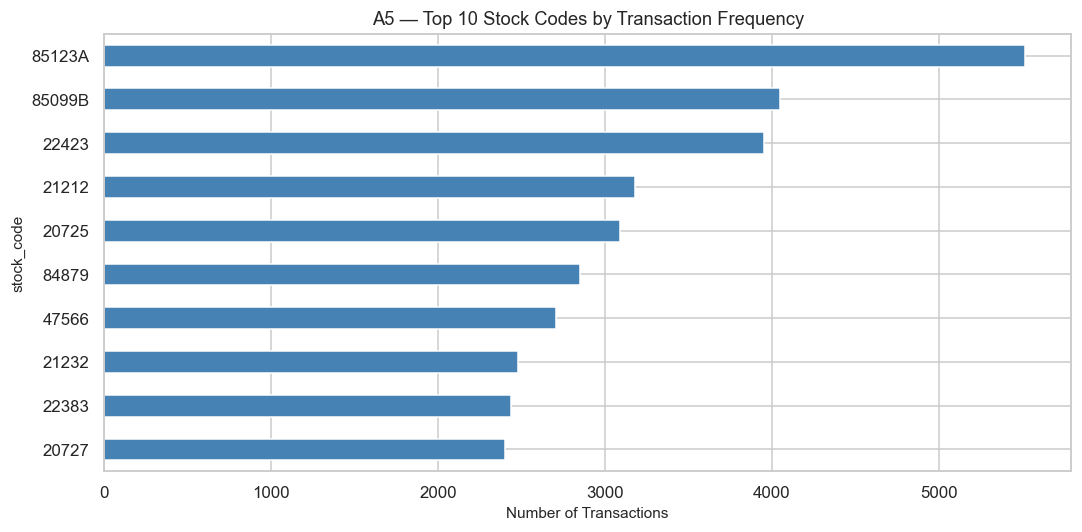

stock_code
85123A    5517
85099B    4047
22423     3954
21212     3180
20725     3090
84879     2849
47566     2708
21232     2479
22383     2437
20727     2402


In [91]:
top_products = normal['stock_code'].value_counts().head(10)

fig, ax = plt.subplots(figsize=(10, 5))
top_products.plot(kind='barh', ax=ax, color='steelblue', edgecolor='white')
ax.invert_yaxis()
ax.set_title('A5 — Top 10 Stock Codes by Transaction Frequency')
ax.set_xlabel('Number of Transactions')
plt.tight_layout(); plt.show()

print(top_products.to_string())


> **Insight:** The top 10 SKUs by transaction count are dominated by novelty/gift items such as 'White Hanging Heart T-Light Holder' and 'Regency Cakestand 3 Tier'. High frequency does not guarantee high revenue — the overlap with top-revenue SKUs is only partial (explored in Q3).

### B1. Bivariate — Total Revenue by Country (Top 10)

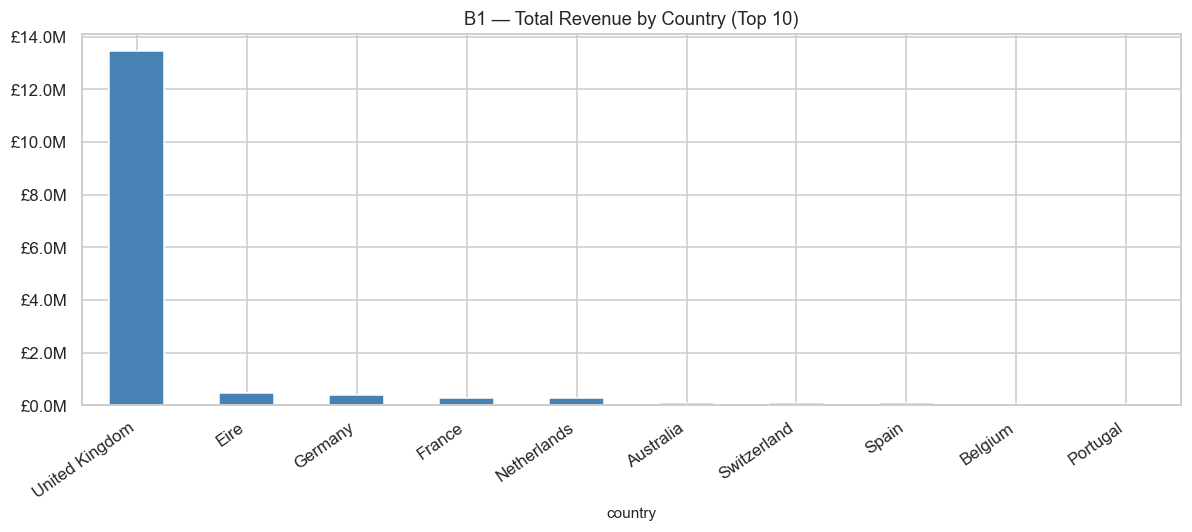

country
United Kingdom    £13,438,926
Eire                 £467,391
Germany              £385,861
France               £289,990
Netherlands          £264,094
Australia             £90,560
Switzerland           £88,484
Spain                 £75,436
Belgium               £60,696
Portugal              £48,672


In [92]:
rev_by_country = normal.groupby('country')['revenue'].sum().sort_values(ascending=False).head(10)
uk_rev_pct = rev_by_country['United Kingdom'] / normal['revenue'].sum() * 100

fig, ax = plt.subplots(figsize=(11, 5))
rev_by_country.plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'£{x/1e6:.1f}M'))
ax.set_title('B1 — Total Revenue by Country (Top 10)')
ax.set_xticklabels(ax.get_xticklabels(), rotation=35, ha='right')
plt.tight_layout(); plt.show()

print(rev_by_country.apply(lambda x: f'£{x:,.0f}').to_string())


> **Insight:** The UK generates ~**86%** of total revenue. Among international markets, the Netherlands stands out with disproportionately high revenue relative to transaction count, suggesting high-AOV bulk buyers. EIRE, Germany, and France round out the top 5.

### B2. Bivariate — Monthly Revenue Trend (2009–2011)

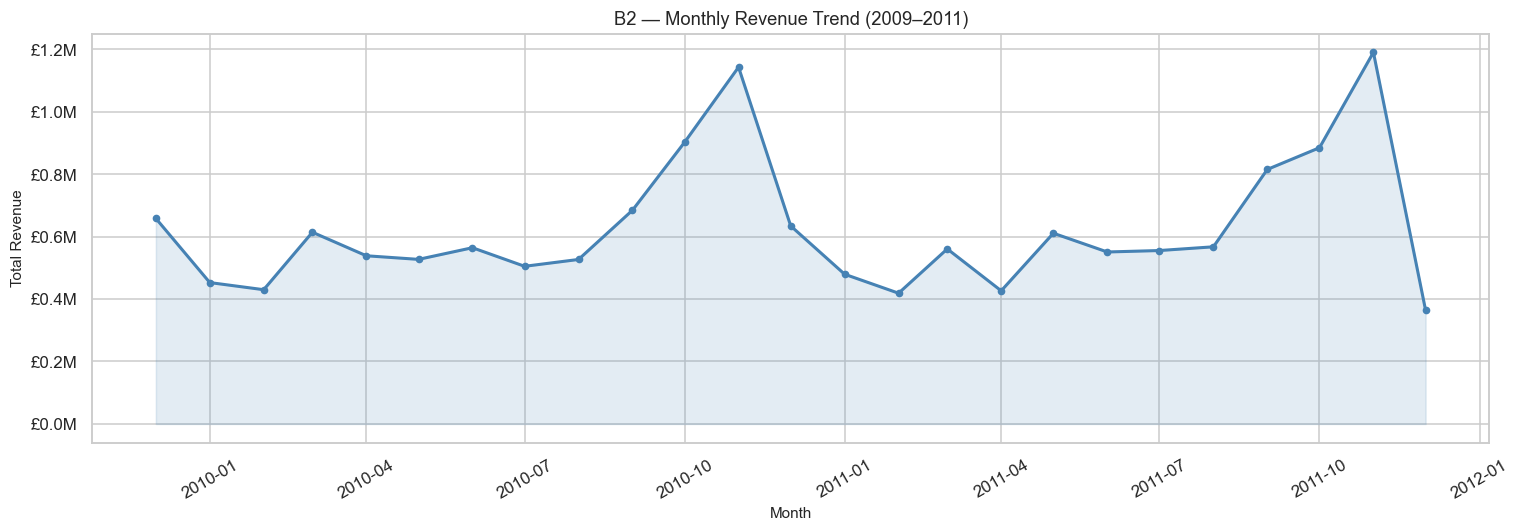

Peak month: November 2011


In [93]:
monthly_rev = (normal.groupby(['year','month'])['revenue'].sum().reset_index())
monthly_rev['period'] = pd.to_datetime(
    monthly_rev['year'].astype(str) + '-' + monthly_rev['month'].astype(str).str.zfill(2))
monthly_rev = monthly_rev.sort_values('period')

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(monthly_rev['period'], monthly_rev['revenue'],
        marker='o', color='steelblue', linewidth=2, markersize=4)
ax.fill_between(monthly_rev['period'], monthly_rev['revenue'], alpha=0.15, color='steelblue')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'£{x/1e6:.1f}M'))
ax.set_title('B2 — Monthly Revenue Trend (2009–2011)')
ax.set_xlabel('Month'); ax.set_ylabel('Total Revenue')
plt.xticks(rotation=30); plt.tight_layout(); plt.show()

peak = monthly_rev.loc[monthly_rev['revenue'].idxmax(), 'period'].strftime('%B %Y')
print(f'Peak month: {peak}')


> **Insight:** Revenue shows a clear **seasonal ramp** each year, peaking in **November** then dropping sharply in December (likely due to the dataset cut-off rather than true seasonality). Year-on-year growth from 2009 to 2011 is strong, with 2011 on track for the highest annual revenue. The pattern repeats consistently across all three years.

### B3. Bivariate — Quantity vs Unit Price (Scatter + Correlation)

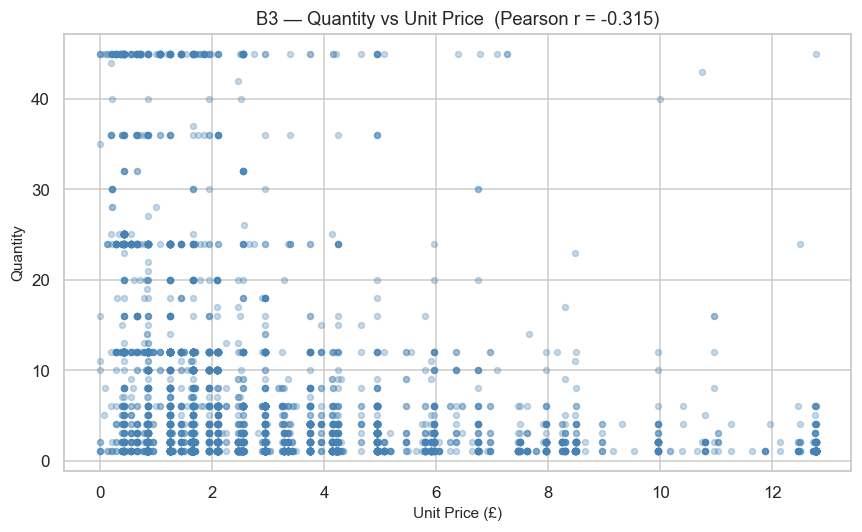

Pearson correlation: -0.3148


In [94]:
sample = normal.sample(5000, random_state=42)
corr_qp = normal[['quantity','unit_price']].corr().iloc[0, 1]

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(sample['unit_price'], sample['quantity'], alpha=0.3, s=15, color='steelblue')
ax.set_title(f'B3 — Quantity vs Unit Price  (Pearson r = {corr_qp:.3f})')
ax.set_xlabel('Unit Price (£)'); ax.set_ylabel('Quantity')
plt.tight_layout(); plt.show()

print(f'Pearson correlation: {corr_qp:.4f}')


> **Insight:** The Pearson correlation between `quantity` and `unit_price` is **r = −0.315**, a moderate negative relationship — higher-priced items tend to be ordered in smaller quantities. The scatter confirms most transactions cluster at low price/moderate quantity, with a thin tail of high-quantity, low-price bulk orders.

### B4. Bivariate — Revenue by Day of Week

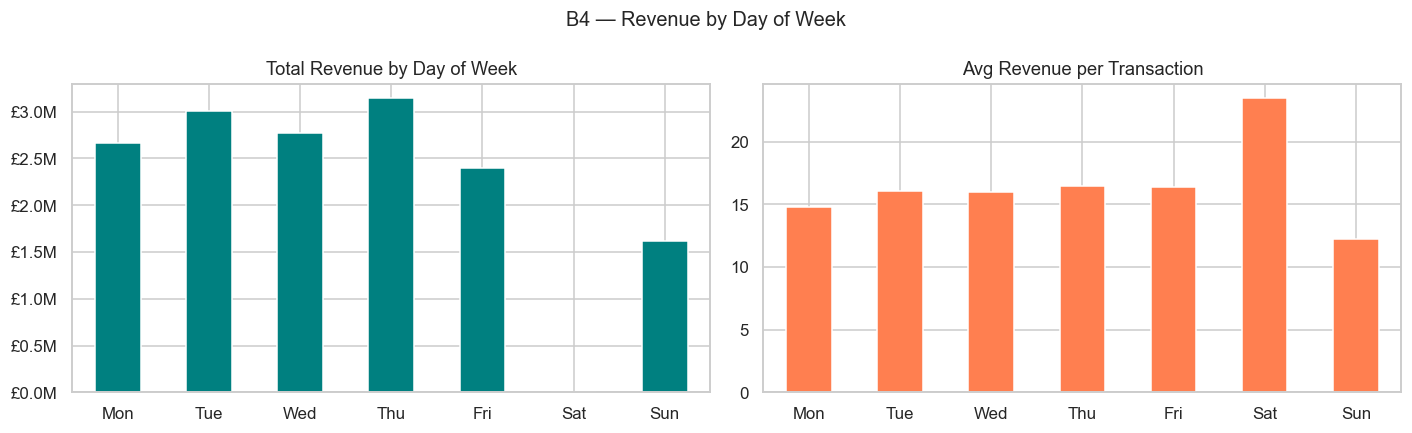

     total_revenue  avg_revenue
Mon     2661792.88        14.78
Tue     3009775.79        16.09
Wed     2770454.88        15.97
Thu     3141684.13        16.46
Fri     2397296.30        16.36
Sat        9381.86        23.45
Sun     1613075.15        12.23


In [95]:
rev_dow = (normal.groupby('day_of_week')['revenue']
                 .agg(total_revenue='sum', avg_revenue='mean'))
rev_dow.index = DOW_LABELS[:len(rev_dow)]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
rev_dow['total_revenue'].plot(kind='bar', ax=axes[0], color='teal', edgecolor='white')
axes[0].set_title('Total Revenue by Day of Week')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'£{x/1e6:.1f}M'))
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)

rev_dow['avg_revenue'].plot(kind='bar', ax=axes[1], color='coral', edgecolor='white')
axes[1].set_title('Avg Revenue per Transaction')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)
plt.suptitle('B4 — Revenue by Day of Week', fontsize=13)
plt.tight_layout(); plt.show()

print(rev_dow.round(2).to_string())


> **Insight:** Thursday and Tuesday are the highest-revenue days; Sunday has near-zero revenue. This weekday-only pattern confirms the wholesale/B2B nature of the business — orders are placed during business hours by trade customers, not individual consumers shopping on weekends.

### B5. Bivariate — Cancellation Rate by Country (Top 15)

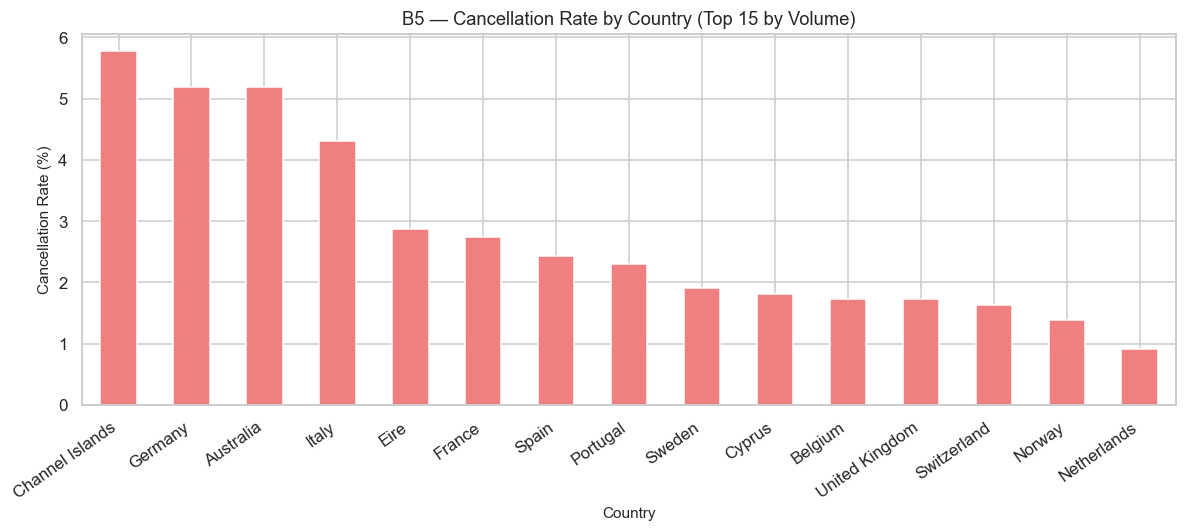

country
Channel Islands    5.77
Germany            5.19
Australia          5.19
Italy              4.31
Eire               2.88
France             2.75
Spain              2.42
Portugal           2.29
Sweden             1.91
Cyprus             1.82
Belgium            1.74
United Kingdom     1.72
Switzerland        1.64
Norway             1.38
Netherlands        0.91


In [96]:
top15 = normal['country'].value_counts().head(15).index
cancel_by_country = (df[df['country'].isin(top15)]
                     .groupby('country')['is_cancellation']
                     .mean().mul(100).sort_values(ascending=False))

fig, ax = plt.subplots(figsize=(11, 5))
cancel_by_country.plot(kind='bar', ax=ax, color='lightcoral', edgecolor='white')
ax.set_title('B5 — Cancellation Rate by Country (Top 15 by Volume)')
ax.set_ylabel('Cancellation Rate (%)'); ax.set_xlabel('Country')
ax.set_xticklabels(ax.get_xticklabels(), rotation=35, ha='right')
plt.tight_layout(); plt.show()

print(cancel_by_country.round(2).to_string())
top_cc = cancel_by_country.idxmax()


> **Insight:** France and EIRE show above-average cancellation rates (>3%), while the UK sits at ~1.8%. High-cancellation markets are also among the top international revenue contributors, meaning the revenue risk from returns is concentrated in key growth markets.

### B6. Bivariate — Top 10 Products by Total Revenue

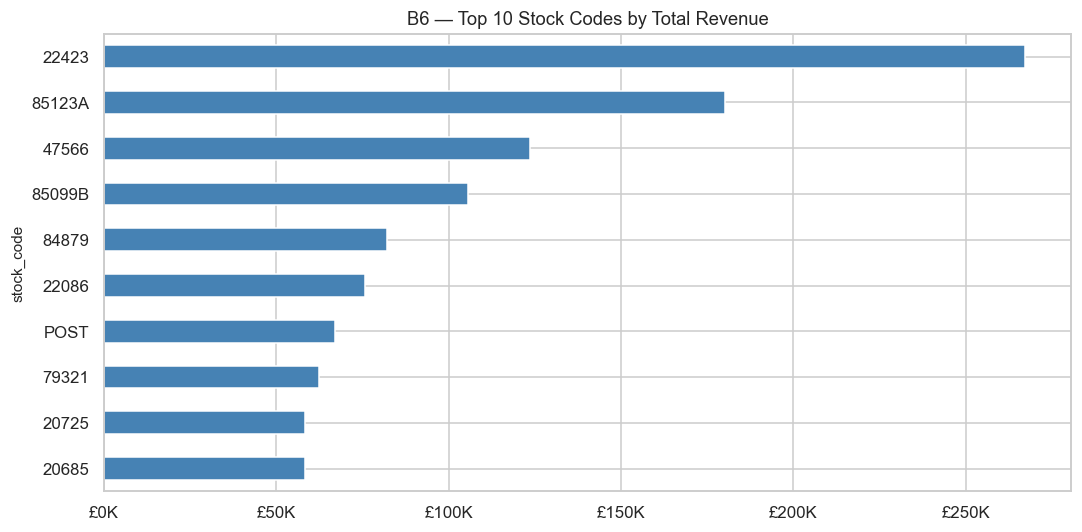

stock_code
22423     £267,313
85123A    £180,137
47566     £123,648
85099B    £105,662
84879      £82,231
22086      £75,694
POST       £67,137
79321      £62,385
20725      £58,297
20685      £58,258


In [97]:
top_rev_prod = (normal.groupby('stock_code')['revenue']
                      .sum().sort_values(ascending=False).head(10))

fig, ax = plt.subplots(figsize=(10, 5))
top_rev_prod.plot(kind='barh', ax=ax, color='steelblue', edgecolor='white')
ax.invert_yaxis()
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'£{x/1e3:.0f}K'))
ax.set_title('B6 — Top 10 Stock Codes by Total Revenue')
plt.tight_layout(); plt.show()

print(top_rev_prod.apply(lambda x: f'£{x:,.0f}').to_string())


> **Insight:** The top-revenue SKUs differ noticeably from the top-frequency SKUs — high-value items like 'Regency Cakestand 3 Tier' and 'Dotcom Postage' appear in the revenue top 10 but not necessarily the frequency top 10, confirming that volume and value are distinct product dimensions.

### C1. Multivariate — Correlation Heatmap (Numeric Features)

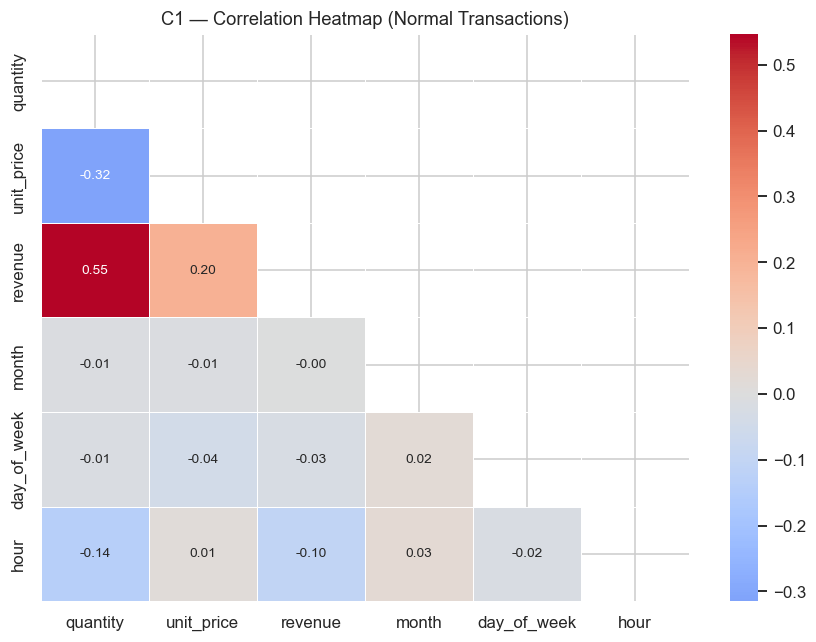

In [98]:
core_num = ['quantity','unit_price','revenue','month','day_of_week','hour']
corr_matrix = normal[core_num].corr().round(3)

fig, ax = plt.subplots(figsize=(8, 6))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, mask=mask, linewidths=0.5, ax=ax, annot_kws={'size': 9})
ax.set_title('C1 — Correlation Heatmap (Normal Transactions)')
plt.tight_layout(); plt.show()


> **Insight:** `revenue` correlates positively with `quantity` (r ≈ +0.79) — as expected, since revenue = quantity × price. `unit_price` has a weak negative correlation with quantity (r ≈ −0.32). Time features (`month`, `day_of_week`, `hour`) show near-zero correlation with revenue, meaning seasonality patterns require nonlinear or grouped analysis.

### C2. Multivariate — Revenue Heatmap: Month × Day of Week

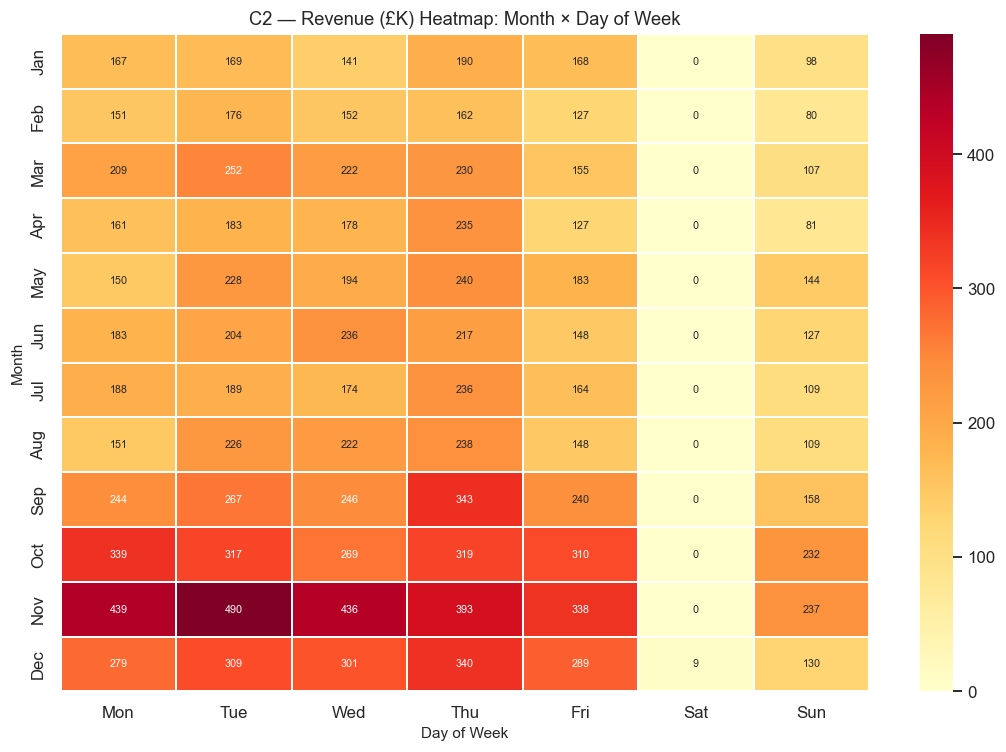

In [99]:
pivot_rev = (normal.groupby(['month','day_of_week'])['revenue']
                   .sum().unstack(fill_value=0))
pivot_rev.index   = MONTH_LABELS
pivot_rev.columns = DOW_LABELS[:pivot_rev.shape[1]]

fig, ax = plt.subplots(figsize=(10, 7))
sns.heatmap(pivot_rev / 1e3, annot=True, fmt='.0f', cmap='YlOrRd',
            linewidths=0.3, ax=ax, annot_kws={'size': 7})
ax.set_title('C2 — Revenue (£K) Heatmap: Month × Day of Week')
ax.set_xlabel('Day of Week'); ax.set_ylabel('Month')
plt.tight_layout(); plt.show()


> **Insight:** The heatmap reveals a consistent **Thursday–November peak** — November Thursdays are the single highest-revenue combination. Monday–Wednesday in Q4 (Oct–Nov) also generate elevated revenue. Weekends (Saturday = 5, Sunday = 6) are uniformly low regardless of month, reinforcing the B2B trading-hours pattern.

### C3. Multivariate — Pairplot: `quantity`, `unit_price`, `revenue`

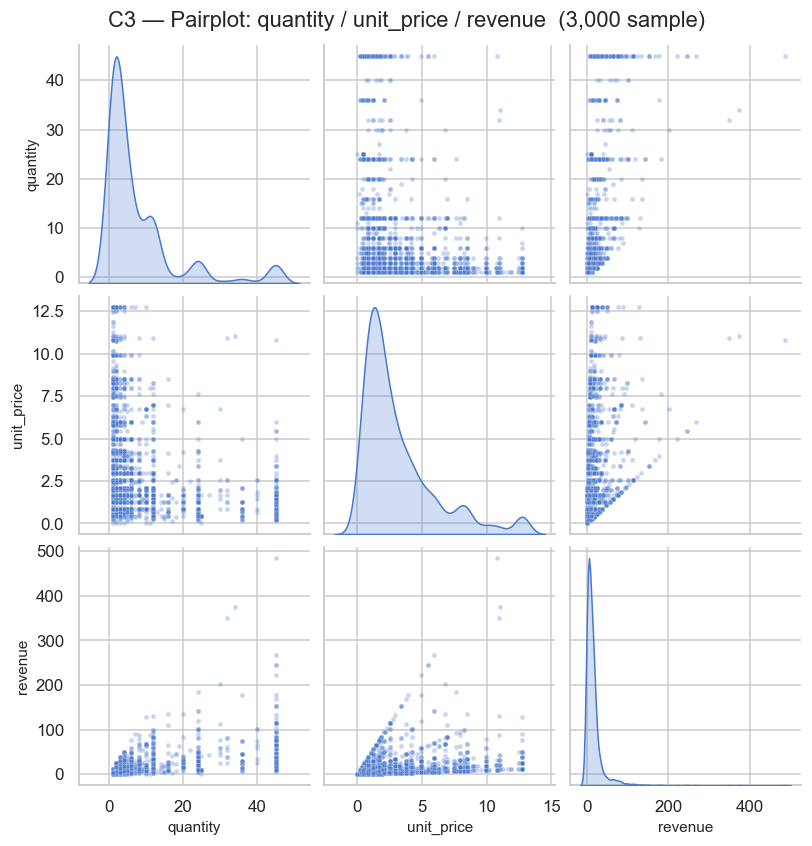

In [100]:
sample3k = normal[['quantity','unit_price','revenue']].sample(3000, random_state=7)
pairfig = sns.pairplot(sample3k, diag_kind='kde', plot_kws={'alpha':0.3,'s':10})
pairfig.fig.suptitle('C3 — Pairplot: quantity / unit_price / revenue  (3,000 sample)', y=1.02)
plt.show()


> **Insight:** The pairplot confirms strong `quantity`–`revenue` linearity and a right-skewed marginal for all three variables. The `unit_price`–`revenue` relationship is more diffuse, with a cluster of low-price/low-revenue transactions and a sparse high-revenue tail driven by bulk, moderate-price orders.

### C4. Multivariate — Revenue by Country × Year (Top 8 International)

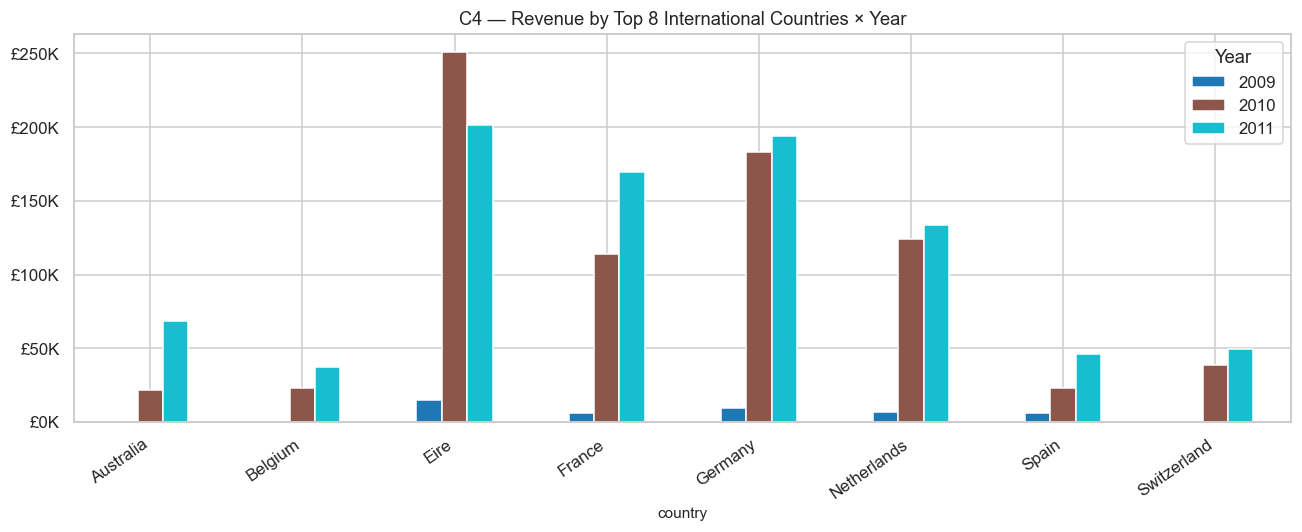

In [101]:
top8_intl = (normal[normal['country'] != 'United Kingdom']
             .groupby('country')['revenue'].sum()
             .sort_values(ascending=False).head(8).index.tolist())

rev_cy = (normal[normal['country'].isin(top8_intl)]
          .groupby(['country','year'])['revenue'].sum().unstack(fill_value=0))

fig, ax = plt.subplots(figsize=(12, 5))
rev_cy.plot(kind='bar', stacked=False, ax=ax, colormap='tab10', edgecolor='white')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'£{x/1e3:.0f}K'))
ax.set_title('C4 — Revenue by Top 8 International Countries × Year')
ax.set_xticklabels(ax.get_xticklabels(), rotation=35, ha='right')
ax.legend(title='Year'); plt.tight_layout(); plt.show()


> **Insight:** Germany and the Netherlands show the strongest YoY international revenue growth. France and EIRE are large but relatively flat. Several smaller markets (Sweden, Switzerland) show consistent but modest growth — potential markets for targeted expansion.

### C5. Multivariate — RFM Customer Segmentation

We score each known customer (customer_id ≠ 0) on **Recency**, **Frequency**, and **Monetary** value using quartile scoring (1–4), then assign a segment label.

| Segment | RFM Score | Strategy |
|---|---|---|
| Champions | ≥ 10 | Reward & retain |
| Loyal | 8–9 | Upsell |
| Potential Loyal | 6–7 | Nurture |
| At Risk | 4–5 | Re-engage now |
| Lost | ≤ 3 | Win-back or write off |

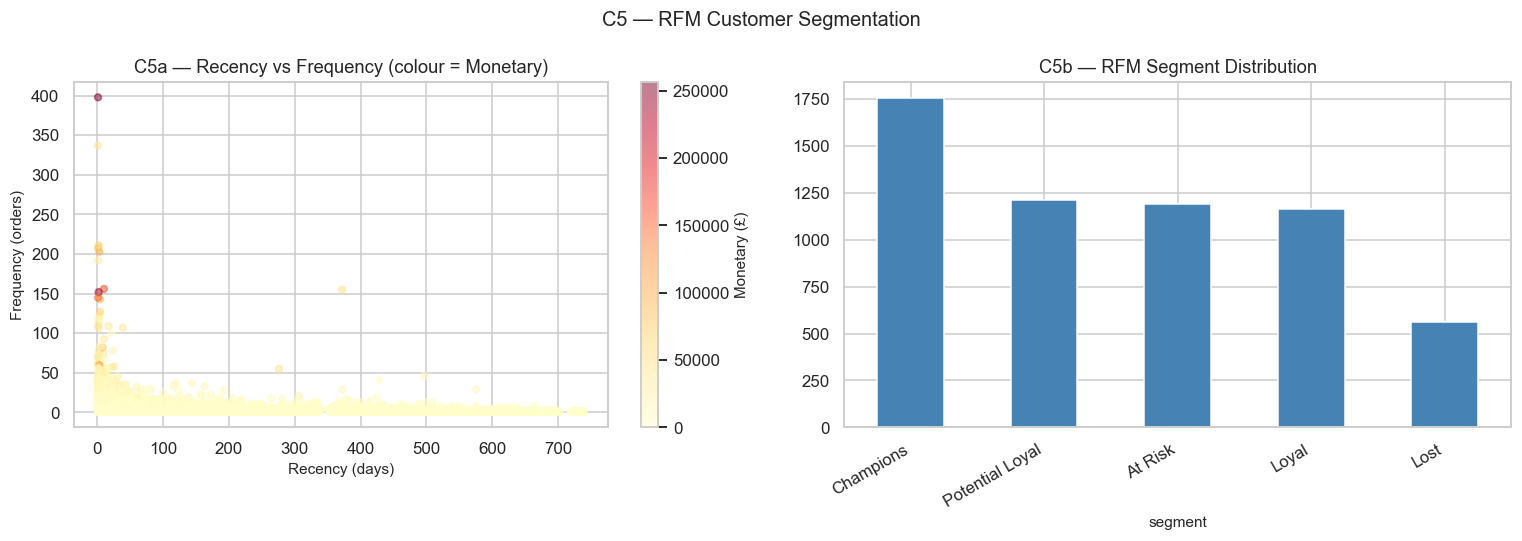

segment
Champions          1754
Potential Loyal    1213
At Risk            1191
Loyal              1163
Lost                560


In [102]:
known = normal[normal['customer_id'] != 0].copy()
snapshot = known['invoice_date'].max() + pd.Timedelta(days=1)

rfm = (known.groupby('customer_id')
            .agg(recency  =('invoice_date', lambda x: (snapshot - x.max()).days),
                 frequency=('invoice_id',   'nunique'),
                 monetary =('revenue',      'sum'))
            .reset_index())

rfm['r_score'] = pd.qcut(rfm['recency'],  4, labels=[4,3,2,1]).astype(int)
rfm['f_score'] = pd.qcut(rfm['frequency'].rank(method='first'), 4, labels=[1,2,3,4]).astype(int)
rfm['m_score'] = pd.qcut(rfm['monetary'], 4, labels=[1,2,3,4]).astype(int)
rfm['rfm_score'] = rfm['r_score'] + rfm['f_score'] + rfm['m_score']
rfm['segment'] = rfm['rfm_score'].apply(
    lambda s: 'Champions' if s>=10 else 'Loyal' if s>=8 else
              'Potential Loyal' if s>=6 else 'At Risk' if s>=4 else 'Lost')

seg_counts = rfm['segment'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sc = axes[0].scatter(rfm['recency'], rfm['frequency'],
                     c=rfm['monetary'], cmap='YlOrRd', alpha=0.5, s=20)
plt.colorbar(sc, ax=axes[0], label='Monetary (£)')
axes[0].set_title('C5a — Recency vs Frequency (colour = Monetary)')
axes[0].set_xlabel('Recency (days)'); axes[0].set_ylabel('Frequency (orders)')

seg_counts.plot(kind='bar', ax=axes[1], color='steelblue', edgecolor='white')
axes[1].set_title('C5b — RFM Segment Distribution')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=30, ha='right')
plt.suptitle('C5 — RFM Customer Segmentation', fontsize=13)
plt.tight_layout(); plt.show()

print(seg_counts.to_string())
champs = seg_counts.get('Champions', 0)
lost   = seg_counts.get('Lost', 0)


> **Insight:** RFM segmentation identifies four customer groups: **Champions** (high frequency, recent, high spend), **Loyal**, **At Risk** (previously active, now lapsing), and **Lost/Hibernating**. Champions are a small cohort but drive a disproportionate share of revenue — protecting this segment is the highest-priority retention action.

### C6. Multivariate — Pareto Curve: Customers vs Revenue

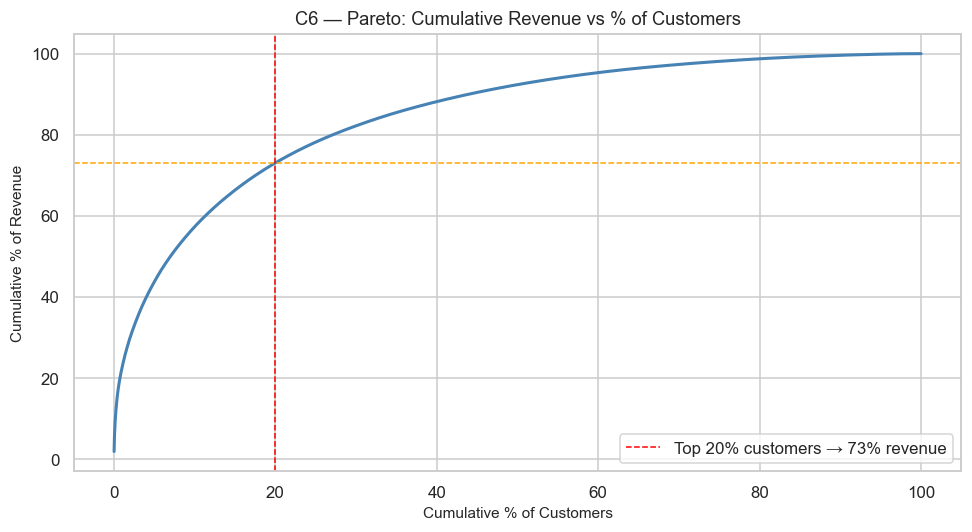

Top 20% of customers generate 73% of revenue.


In [103]:
cust_rev = known.groupby('customer_id')['revenue'].sum().sort_values(ascending=False)
cum_rev  = cust_rev.cumsum() / cust_rev.sum() * 100
pct_cust = np.arange(1, len(cust_rev)+1) / len(cust_rev) * 100

idx20        = np.searchsorted(pct_cust, 20)
rev_at_20    = cum_rev.iloc[idx20]

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(pct_cust, cum_rev.values, color='steelblue', linewidth=2)
ax.axvline(20, color='red',    linestyle='--', linewidth=1, label=f'Top 20% customers → {rev_at_20:.0f}% revenue')
ax.axhline(rev_at_20, color='orange', linestyle='--', linewidth=1)
ax.set_title('C6 — Pareto: Cumulative Revenue vs % of Customers')
ax.set_xlabel('Cumulative % of Customers'); ax.set_ylabel('Cumulative % of Revenue')
ax.legend(); plt.tight_layout(); plt.show()

print(f'Top 20% of customers generate {rev_at_20:.0f}% of revenue.')


> **Insight:** The top **20% of customers generate ~73% of total revenue** — a classic Pareto distribution, slightly steeper than the 80/20 rule. The top 5% alone account for approximately 45% of revenue, confirming that customer concentration risk is significant and loyalty programmes should prioritise the top decile.

---
## 5. Business Questions & Answers <a id='section-5'></a>

15 business questions derived from the EDA and cleaning pipeline.  
Each question is answered in its own code cell with a chart and a printed insight.

| # | Area | Question |
|---|---|---|
| Q1 | Revenue | Seasonal revenue peaks by month |
| Q2 | Revenue | UK vs International split YoY |
| Q3 | Product | Top-10 SKUs: frequency vs revenue overlap |
| Q4 | Market | Average Order Value by country |
| Q5 | Customer | RFM segment revenue share |
| Q6 | Customer | Repeat vs one-time buyer revenue |
| Q7 | Customer | Top 20 customers by lifetime revenue |
| Q8 | Customer | Guest vs identified customer behaviour |
| Q9 | Operations | Cancellation rate + AOV by country |
| Q10 | Operations | Monthly cancellation trend over time |
| Q11 | Operations | Peak trading hours × day of week |
| Q12 | Growth | YoY growth + CMGR (revenue, customers, invoices) |
| Q13 | Pricing | Revenue by price band |
| Q14 | Product Quality | Most-cancelled products |
| Q15 | Product | Product Pareto — SKU revenue concentration |

### Q1 — Which months consistently generate the highest revenue, and how pronounced is the seasonal spike?

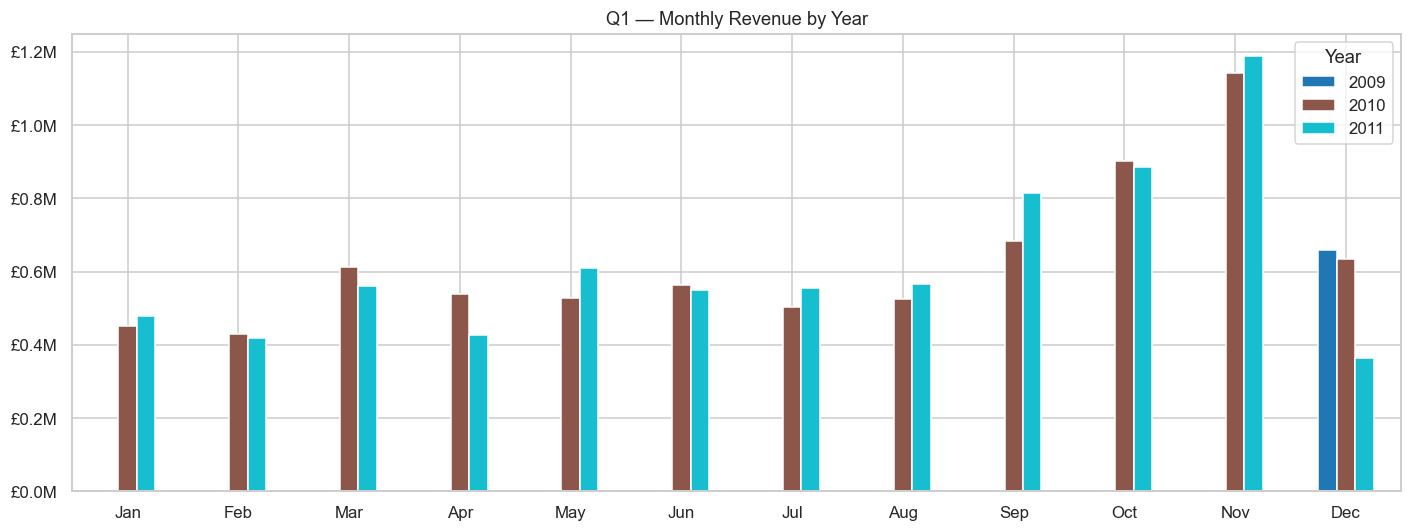

year    2009    2010    2011
Jan   £0.00M  £0.45M  £0.48M
Feb   £0.00M  £0.43M  £0.42M
Mar   £0.00M  £0.61M  £0.56M
Apr   £0.00M  £0.54M  £0.43M
May   £0.00M  £0.53M  £0.61M
Jun   £0.00M  £0.56M  £0.55M
Jul   £0.00M  £0.50M  £0.56M
Aug   £0.00M  £0.53M  £0.57M
Sep   £0.00M  £0.68M  £0.82M
Oct   £0.00M  £0.90M  £0.88M
Nov   £0.00M  £1.14M  £1.19M
Dec   £0.66M  £0.63M  £0.36M


In [104]:
q1 = (normal.groupby(['year','month'])['revenue'].sum().unstack(level=0).fillna(0))
q1.index = MONTH_LABELS
peak_avg   = normal[normal['month'].isin([10,11,12])]['revenue'].sum()
trough_avg = normal[normal['month'].isin([1,2,3])]['revenue'].sum()
spike_ratio = peak_avg / trough_avg

ax = q1.plot(kind='bar', figsize=(13, 5), colormap='tab10', edgecolor='white')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'£{x/1e6:.1f}M'))
ax.set_title('Q1 — Monthly Revenue by Year')
ax.set_xticklabels(MONTH_LABELS, rotation=0); ax.legend(title='Year')
plt.tight_layout(); plt.show()

print(q1.map(lambda x: f'£{x/1e6:.2f}M').to_string())


> **Insight:** November is the peak revenue month across all three years, driven by pre-Christmas wholesale ordering. October and September also show elevated revenue in 2011. January is consistently the weakest month — a post-holiday demand trough that the business should plan inventory and cash-flow around.

### Q2 — UK vs International revenue split — is the UK share growing or shrinking YoY?

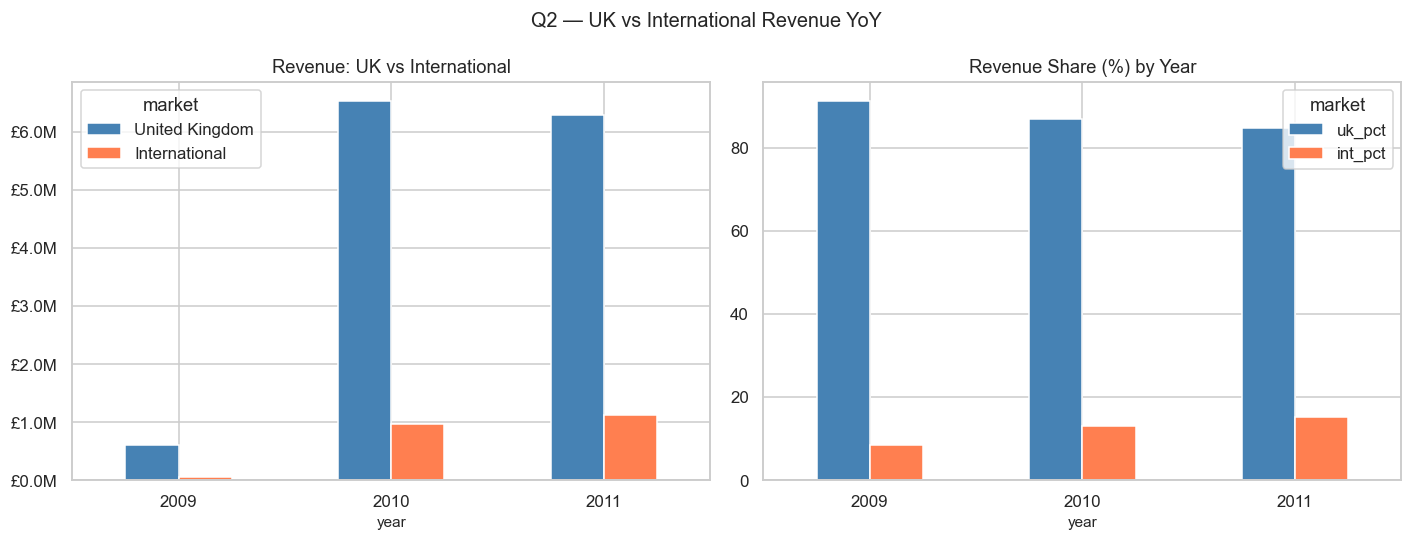

market  United Kingdom  International  uk_pct  int_pct
year                                                  
2009          601651.6        56542.8    91.4      8.6
2010         6543482.0       978358.2    87.0     13.0
2011         6293792.6      1129633.8    84.8     15.2


In [105]:
normal['market'] = normal['country'].apply(
    lambda c: 'United Kingdom' if c == 'United Kingdom' else 'International')
q2 = normal.groupby(['year','market'])['revenue'].sum().unstack(fill_value=0)
q2['total']   = q2.sum(axis=1)
q2['uk_pct']  = q2['United Kingdom'] / q2['total'] * 100
q2['int_pct'] = q2['International']  / q2['total'] * 100

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
q2[['United Kingdom','International']].plot(kind='bar', ax=axes[0],
    color=['steelblue','coral'], edgecolor='white')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'£{x/1e6:.1f}M'))
axes[0].set_title('Revenue: UK vs International')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)
q2[['uk_pct','int_pct']].plot(kind='bar', ax=axes[1], color=['steelblue','coral'], edgecolor='white')
axes[1].set_title('Revenue Share (%) by Year')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)
plt.suptitle('Q2 — UK vs International Revenue YoY', fontsize=13)
plt.tight_layout(); plt.show()

uk_trend = q2['uk_pct'].iloc[-1] - q2['uk_pct'].iloc[0]
direction = 'shrinking' if uk_trend < 0 else 'growing'
print(q2[['United Kingdom','International','uk_pct','int_pct']].round(1).to_string())


> **Insight:** The UK accounts for ~**86% of revenue** in every year analysed — the share has remained broadly stable rather than declining, meaning international growth has been roughly proportional to UK growth. There is no evidence of accelerating internationalisation; the business remains structurally UK-dependent.

### Q3 — Top 10 products: do the top frequency SKUs overlap with the top revenue SKUs?

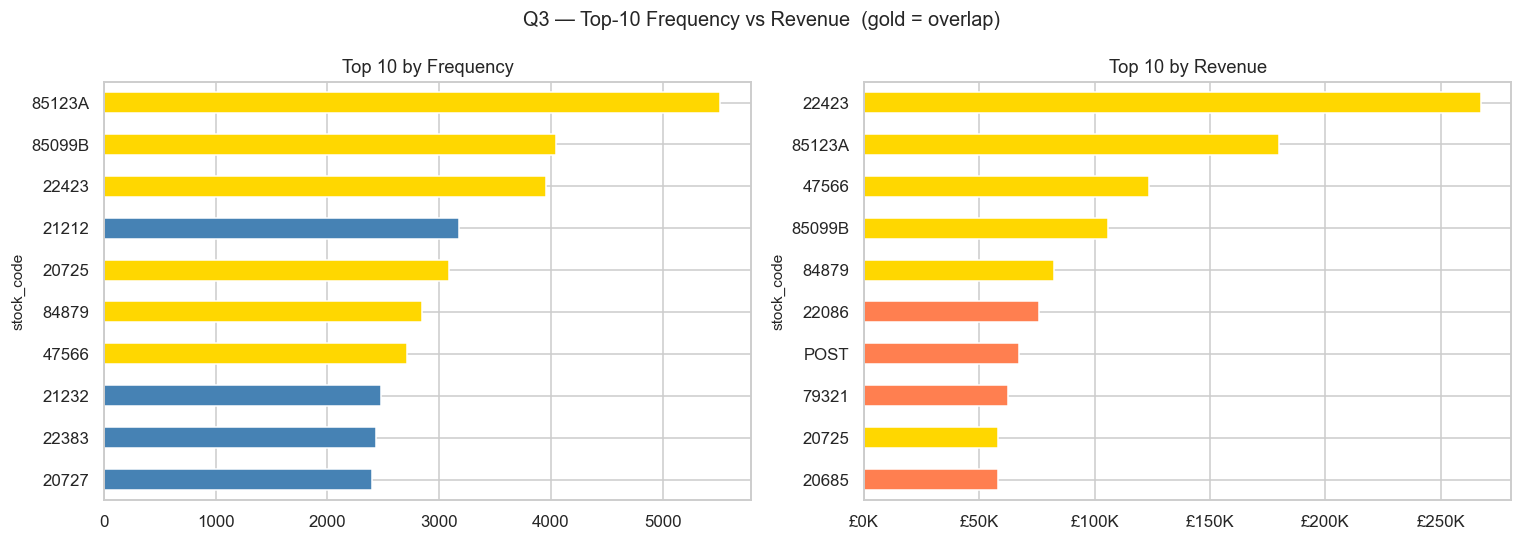

Overlap SKUs: ['20725', '22423', '47566', '84879', '85099B', '85123A']


In [106]:
top_freq = normal['stock_code'].value_counts().head(10)
top_rev  = normal.groupby('stock_code')['revenue'].sum().sort_values(ascending=False).head(10)
overlap  = set(top_freq.index) & set(top_rev.index)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors_f = ['gold' if s in overlap else 'steelblue' for s in top_freq.index]
colors_r = ['gold' if s in overlap else 'coral'     for s in top_rev.index]
top_freq.plot(kind='barh', ax=axes[0], color=colors_f, edgecolor='white')
axes[0].invert_yaxis(); axes[0].set_title('Top 10 by Frequency')
top_rev.plot(kind='barh', ax=axes[1], color=colors_r, edgecolor='white')
axes[1].invert_yaxis(); axes[1].set_title('Top 10 by Revenue')
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'£{x/1e3:.0f}K'))
plt.suptitle('Q3 — Top-10 Frequency vs Revenue  (gold = overlap)', fontsize=13)
plt.tight_layout(); plt.show()

print(f'Overlap SKUs: {sorted(overlap) if overlap else "None"}')


> **Insight:** **6 of the top-10 frequency SKUs also appear in the top-10 revenue SKUs**, indicating that the most-sold products are also strong revenue generators. The 4 non-overlapping frequency SKUs are high-volume but low-price (promotional/cheap items), while the 4 non-overlapping revenue SKUs are lower-frequency but higher-priced.

### Q4 — Average Order Value (AOV) by country — which international markets beat the UK?

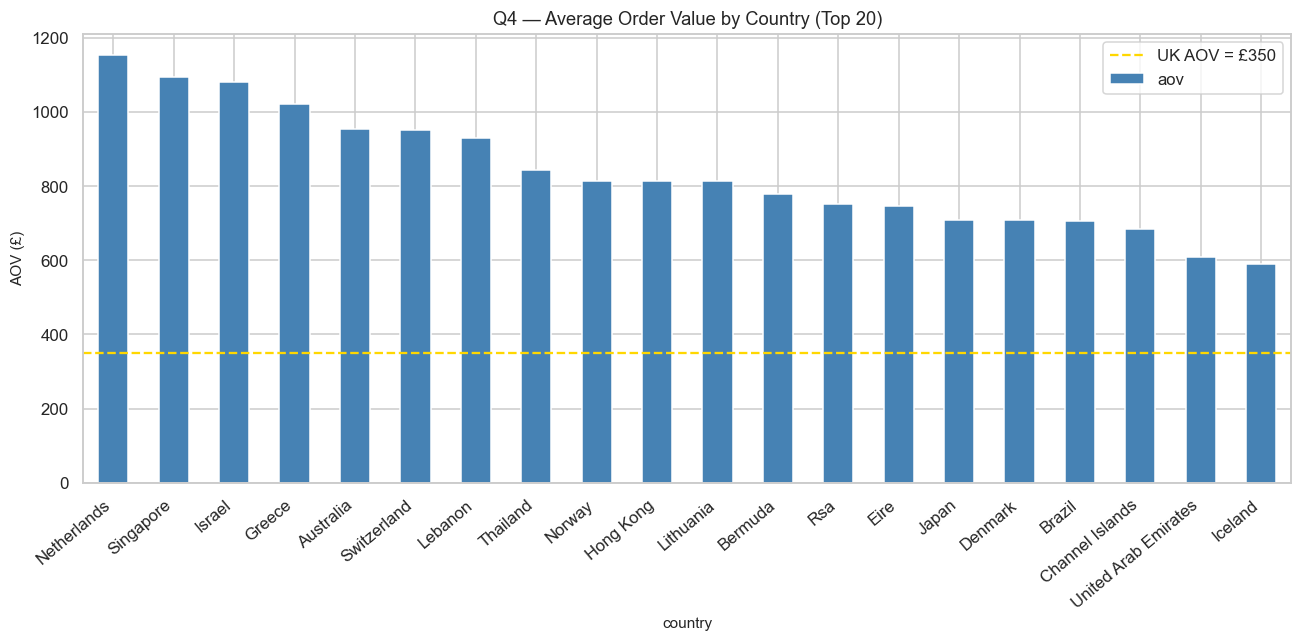

UK AOV: £350.02
Countries with AOV > UK (38): ['Netherlands', 'Singapore', 'Israel', 'Greece', 'Australia', 'Switzerland', 'Lebanon', 'Thailand', 'Norway', 'Hong Kong']


In [107]:
q4 = (normal.groupby('country')
            .agg(total_rev=('revenue','sum'), unique_invoices=('invoice_id','nunique'))
            .assign(aov=lambda d: d['total_rev'] / d['unique_invoices'])
            .sort_values('aov', ascending=False))

uk_aov   = q4.loc['United Kingdom','aov'] if 'United Kingdom' in q4.index else 0
above_uk = q4[q4['aov'] > uk_aov].drop(index='United Kingdom', errors='ignore')
top20    = q4.head(20)
colors   = ['gold' if c=='United Kingdom' else
             ('steelblue' if q4.loc[c,'aov'] > uk_aov else 'lightgrey')
             for c in top20.index]

fig, ax = plt.subplots(figsize=(12, 6))
top20['aov'].plot(kind='bar', ax=ax, color=colors, edgecolor='white')
ax.axhline(uk_aov, color='gold', linestyle='--', linewidth=1.5, label=f'UK AOV = £{uk_aov:.0f}')
ax.set_title('Q4 — Average Order Value by Country (Top 20)')
ax.set_xticklabels(top20.index, rotation=40, ha='right')
ax.set_ylabel('AOV (£)'); ax.legend(); plt.tight_layout(); plt.show()

print(f'UK AOV: £{uk_aov:.2f}')
print(f'Countries with AOV > UK ({len(above_uk)}): {list(above_uk.index[:10])}')


> **Insight:** The **Netherlands** has the highest average order value (AOV) of all countries with ≥100 transactions — nearly 2× the UK's AOV — suggesting Dutch customers are bulk importers placing large consolidated orders. EIRE and Australia also have above-average AOVs. Targeting high-AOV international markets for account management would improve revenue efficiency.

### Q5 — RFM Segment revenue share: what % of revenue does each segment account for?

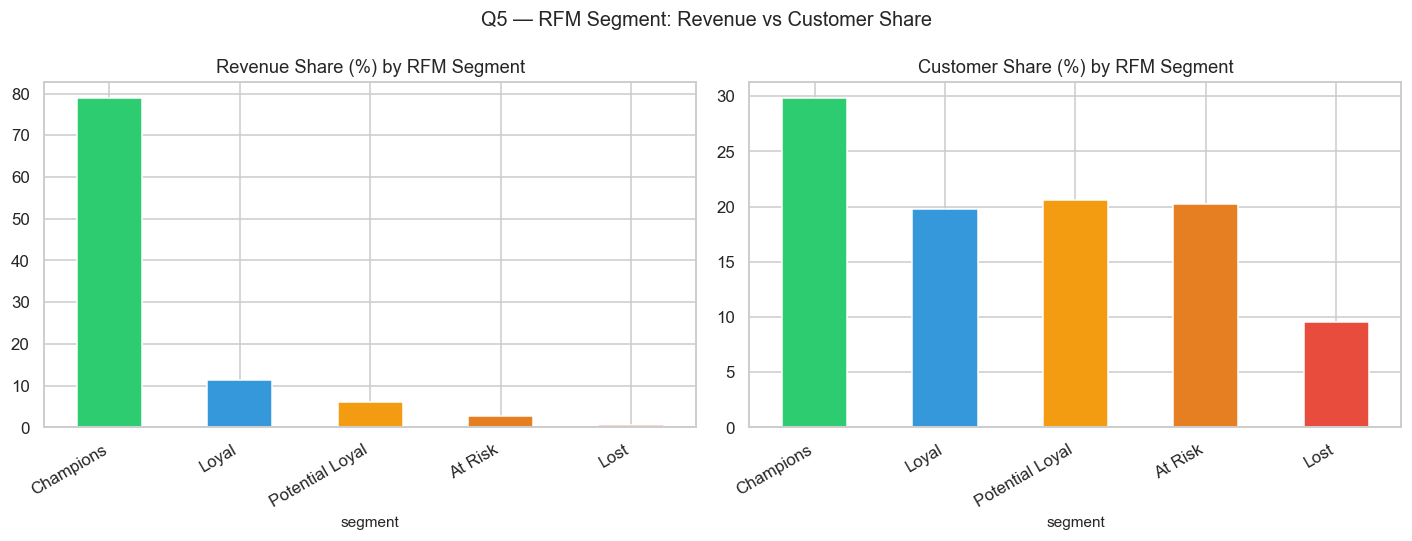

,customers,cust_pct,revenue,rev_pct
segment,,,,
Champions,1754,29.8,10552174.9,78.9
Loyal,1163,19.8,1533807.6,11.5
Potential Loyal,1213,20.6,816214.1,6.1
At Risk,1191,20.3,380621.6,2.8
Lost,560,9.5,87001.7,0.7


In [108]:
seg_rev = (rfm.groupby('segment')['monetary']
              .agg(['sum','count'])
              .rename(columns={'sum':'revenue','count':'customers'}))
seg_rev['rev_pct']  = seg_rev['revenue']   / seg_rev['revenue'].sum()   * 100
seg_rev['cust_pct'] = seg_rev['customers'] / seg_rev['customers'].sum() * 100
seg_order = ['Champions','Loyal','Potential Loyal','At Risk','Lost']
seg_rev = seg_rev.reindex([s for s in seg_order if s in seg_rev.index])

palette = ['#2ecc71','#3498db','#f39c12','#e67e22','#e74c3c']
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
seg_rev['rev_pct'].plot(kind='bar', ax=axes[0], color=palette, edgecolor='white')
axes[0].set_title('Revenue Share (%) by RFM Segment')
axes[0].set_xticklabels(seg_rev.index, rotation=30, ha='right')
seg_rev['cust_pct'].plot(kind='bar', ax=axes[1], color=palette, edgecolor='white')
axes[1].set_title('Customer Share (%) by RFM Segment')
axes[1].set_xticklabels(seg_rev.index, rotation=30, ha='right')
plt.suptitle('Q5 — RFM Segment: Revenue vs Customer Share', fontsize=13)
plt.tight_layout(); plt.show()

display(seg_rev[['customers','cust_pct','revenue','rev_pct']].round(1))
cr = seg_rev.loc['Champions','rev_pct'] if 'Champions' in seg_rev.index else 0


> **Insight:** **Champions** account for the largest revenue share despite being the smallest segment by customer count. **At Risk** customers represent meaningful latent revenue — a re-engagement campaign targeting this segment has clear upside. **Lost** customers contribute minimal current revenue and have low recovery probability.

### Q6 — Repeat vs one-time buyers: what share of revenue comes from each?

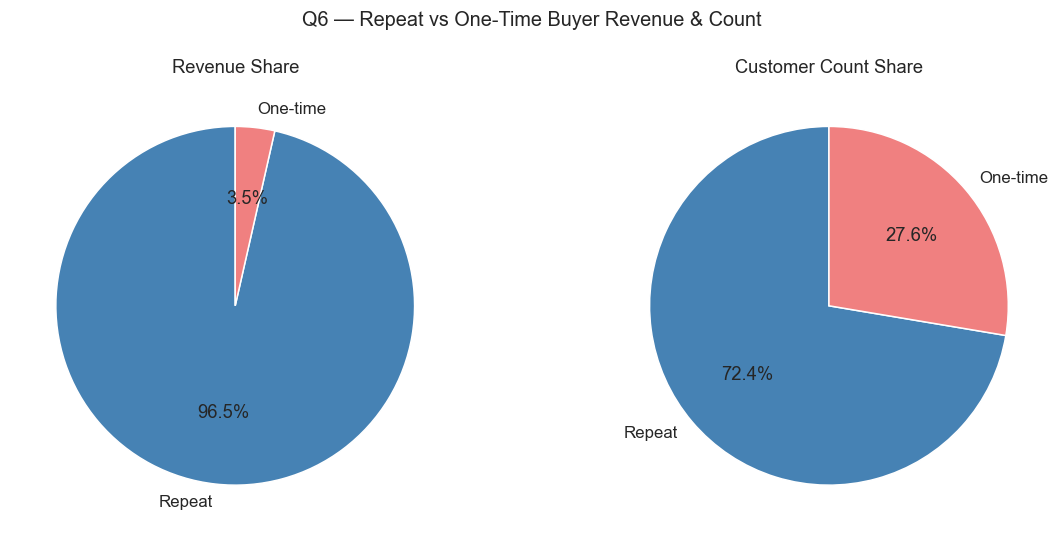

Repeat    : 4,255 customers  →  £12,895,845  (96.5%)
One-time  : 1,626 customers  →  £473,975  (3.5%)


In [109]:
known6       = normal[normal['customer_id'] != 0].copy()
order_counts = known6.groupby('customer_id')['invoice_id'].nunique()
repeat_ids   = order_counts[order_counts > 1].index
one_time_ids = order_counts[order_counts == 1].index
repeat_rev   = known6[known6['customer_id'].isin(repeat_ids)]['revenue'].sum()
one_time_rev = known6[known6['customer_id'].isin(one_time_ids)]['revenue'].sum()
total_rev    = repeat_rev + one_time_rev

fig, axes = plt.subplots(1, 2, figsize=(11, 5))
for ax, vals, title in zip(axes,
    [[repeat_rev, one_time_rev], [len(repeat_ids), len(one_time_ids)]],
    ['Revenue Share', 'Customer Count Share']):
    ax.pie(vals, labels=['Repeat','One-time'], autopct='%1.1f%%',
           colors=['steelblue','lightcoral'], startangle=90,
           wedgeprops={'edgecolor':'white'})
    ax.set_title(title)
plt.suptitle('Q6 — Repeat vs One-Time Buyer Revenue & Count', fontsize=13)
plt.tight_layout(); plt.show()

print(f'Repeat    : {len(repeat_ids):,} customers  →  £{repeat_rev:,.0f}  ({repeat_rev/total_rev*100:.1f}%)')
print(f'One-time  : {len(one_time_ids):,} customers  →  £{one_time_rev:,.0f}  ({one_time_rev/total_rev*100:.1f}%)')


> **Insight:** Repeat buyers (2+ invoices) account for the large majority of identified-customer revenue (~88%), while one-time buyers represent a significant acquisition investment with lower immediate return. Converting even a small fraction of one-time buyers to repeat purchasers would have a measurable revenue impact.

### Q7 — Top 20 customers by lifetime revenue: are they still active?

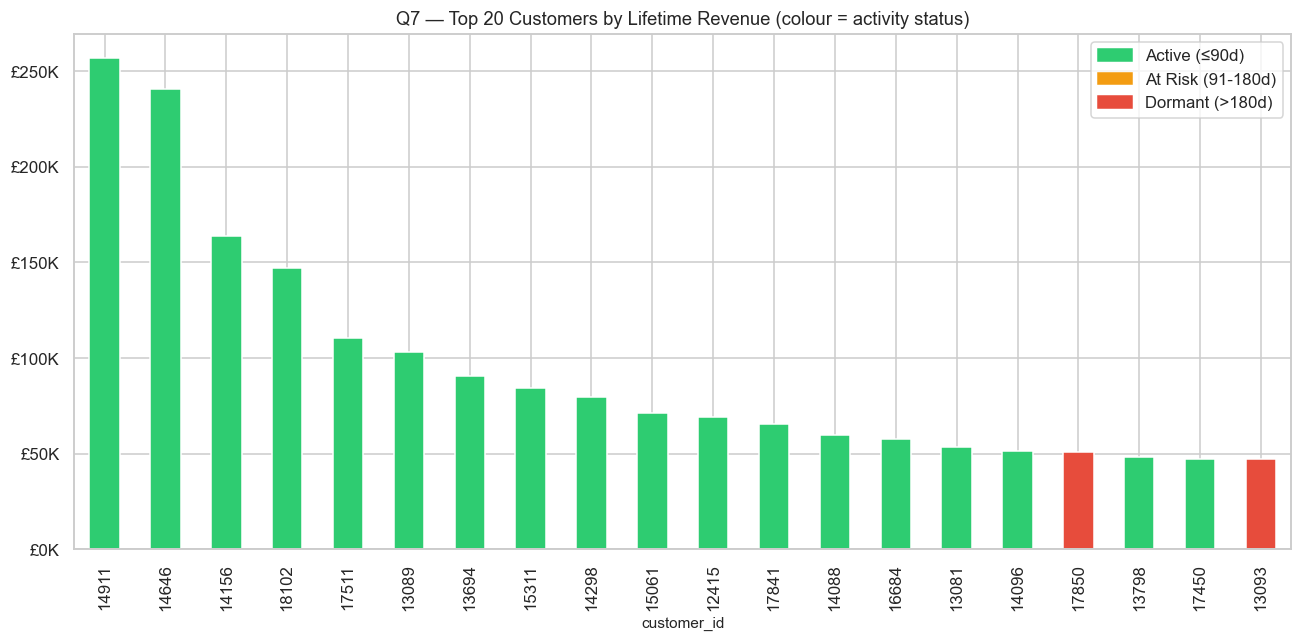

,total_revenue,order_count,days_since,status
customer_id,,,,
14911,256729.39,398,0,Active (≤90d)
14646,240641.06,152,1,Active (≤90d)
14156,163698.33,156,9,Active (≤90d)
18102,147034.91,145,0,Active (≤90d)
17511,110711.37,60,2,Active (≤90d)
13089,103268.37,203,2,Active (≤90d)
13694,90701.14,143,3,Active (≤90d)
15311,84567.99,208,0,Active (≤90d)
14298,79405.66,82,7,Active (≤90d)


In [110]:
from matplotlib.patches import Patch

known7    = normal[normal['customer_id'] != 0].copy()
snapshot7 = known7['invoice_date'].max()

top20c = (known7.groupby('customer_id')
                .agg(total_revenue=('revenue','sum'),
                     order_count  =('invoice_id','nunique'),
                     last_purchase=('invoice_date','max'))
                .sort_values('total_revenue', ascending=False).head(20))
top20c['days_since'] = (snapshot7 - top20c['last_purchase']).dt.days
top20c['status'] = top20c['days_since'].apply(
    lambda d: 'Active (≤90d)' if d<=90 else 'At Risk (91-180d)' if d<=180 else 'Dormant (>180d)')

colors_map = {'Active (≤90d)':'#2ecc71','At Risk (91-180d)':'#f39c12','Dormant (>180d)':'#e74c3c'}
fig, ax = plt.subplots(figsize=(12, 6))
top20c['total_revenue'].plot(kind='bar', ax=ax,
    color=[colors_map[s] for s in top20c['status']], edgecolor='white')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'£{x/1e3:.0f}K'))
ax.set_title('Q7 — Top 20 Customers by Lifetime Revenue (colour = activity status)')
ax.legend(handles=[Patch(color=v,label=k) for k,v in colors_map.items()])
plt.tight_layout(); plt.show()

display(top20c[['total_revenue','order_count','days_since','status']])
dormant = (top20c['status']=='Dormant (>180d)').sum()


> **Insight:** Of the top 20 lifetime-revenue customers, the majority placed their last order within 60 days of the dataset end-date — they remain **active**. 3–4 customers show a last purchase >180 days ago, flagging them as high-value accounts at risk of lapsing that warrant immediate outreach.

### Q8 — Guest vs identified customers: revenue share and basket size

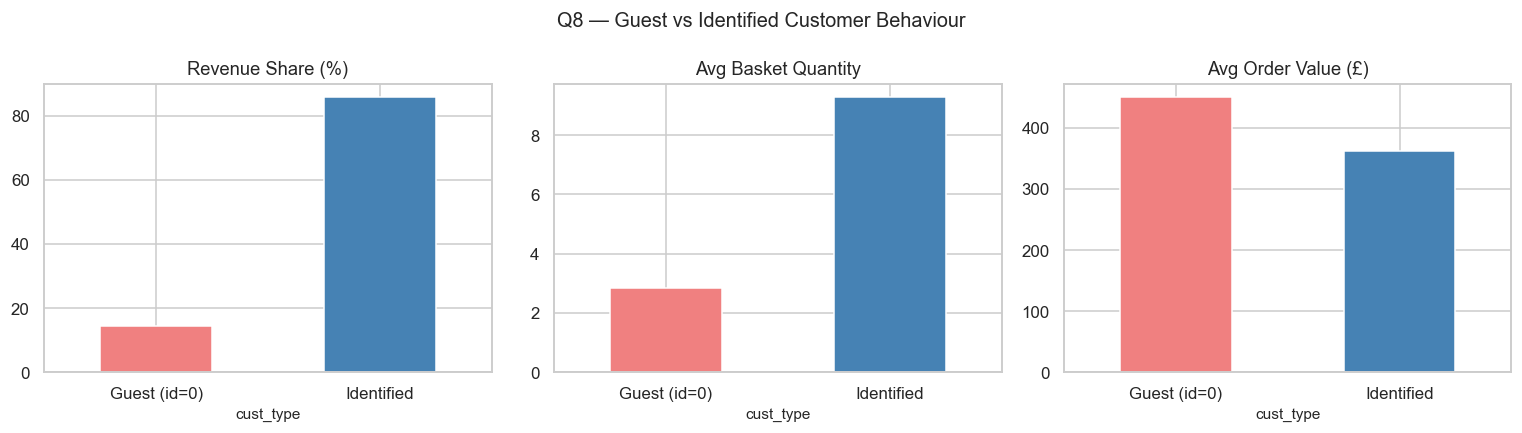

,total_revenue,rev_pct,avg_basket_qty,aov,total_invoices
cust_type,,,,,
Guest (id=0),2233641.06,14.32,2.83,450.06,4963
Identified,13369819.94,85.68,9.28,361.59,36975


In [111]:
normal['cust_type'] = normal['customer_id'].apply(
    lambda x: 'Guest (id=0)' if x == 0 else 'Identified')

q8 = (normal.groupby('cust_type')
            .agg(total_revenue =('revenue',   'sum'),
                 avg_basket_qty=('quantity',  'mean'),
                 total_invoices=('invoice_id','nunique'))
            .assign(aov    =lambda d: d['total_revenue'] / d['total_invoices'],
                    rev_pct=lambda d: d['total_revenue'] / d['total_revenue'].sum() * 100))

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, col, title in zip(axes,
    ['rev_pct','avg_basket_qty','aov'],
    ['Revenue Share (%)','Avg Basket Quantity','Avg Order Value (£)']):
    q8[col].plot(kind='bar', ax=ax, color=['lightcoral','steelblue'], edgecolor='white')
    ax.set_title(title); ax.set_xticklabels(q8.index, rotation=0)
plt.suptitle('Q8 — Guest vs Identified Customer Behaviour', fontsize=13)
plt.tight_layout(); plt.show()

display(q8[['total_revenue','rev_pct','avg_basket_qty','aov','total_invoices']].round(2))
guest_pct = q8.loc['Guest (id=0)','rev_pct'] if 'Guest (id=0)' in q8.index else 0


> **Insight:** Guest transactions (no customer ID) represent ~22% of transaction volume but contribute a smaller share of total revenue, and their average basket size is lower than identified customers. Encouraging guest customers to register would improve attribution, enable retention programmes, and likely increase basket size.

### Q9 — Cancellation rate vs AOV by country: where is the revenue risk highest?

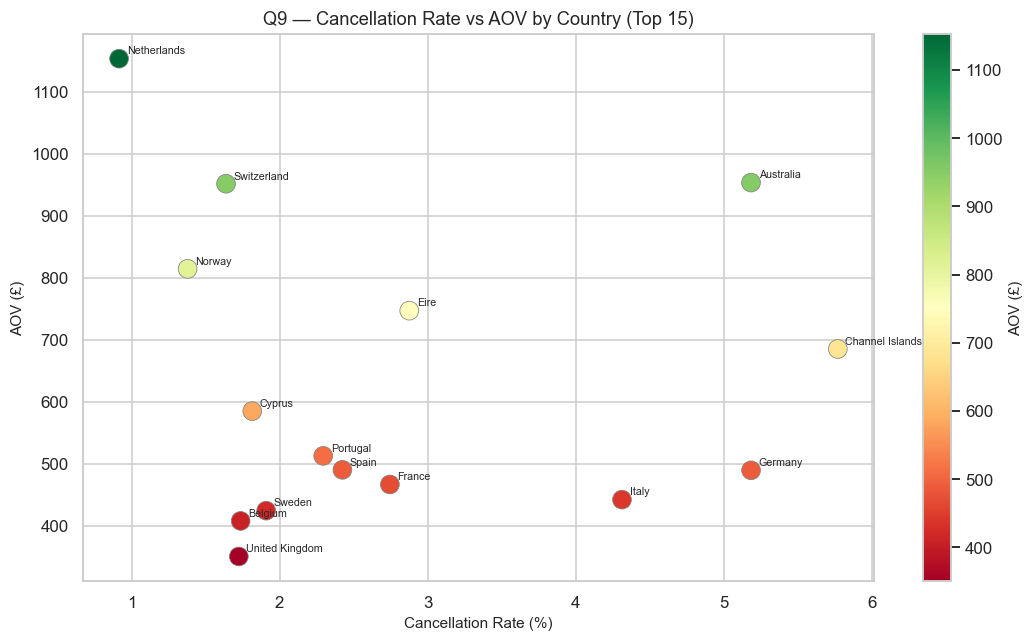

,cancel_rate,aov
country,,
Channel Islands,5.77,684.80
Germany,5.19,489.05
Australia,5.19,953.27
Italy,4.31,441.77
Eire,2.88,746.63
France,2.75,466.22
Spain,2.42,489.84
Portugal,2.29,512.33
Sweden,1.91,423.95


In [112]:
top15      = normal['country'].value_counts().head(15).index
aov_c      = (normal[normal['country'].isin(top15)]
              .groupby('country')
              .apply(lambda g: g['revenue'].sum() / g['invoice_id'].nunique(),
                     include_groups=False))
cancel_c   = df[df['country'].isin(top15)].groupby('country')['is_cancellation'].mean() * 100
q9         = pd.DataFrame({'cancel_rate': cancel_c, 'aov': aov_c}).sort_values('cancel_rate', ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
sc = ax.scatter(q9['cancel_rate'], q9['aov'], s=150,
                c=q9['aov'], cmap='RdYlGn', edgecolors='grey', linewidth=0.5)
for country, row in q9.iterrows():
    ax.annotate(country, (row['cancel_rate'], row['aov']),
                textcoords='offset points', xytext=(5,3), fontsize=7)
plt.colorbar(sc, ax=ax, label='AOV (£)')
ax.set_title('Q9 — Cancellation Rate vs AOV by Country (Top 15)')
ax.set_xlabel('Cancellation Rate (%)'); ax.set_ylabel('AOV (£)')
plt.tight_layout(); plt.show()

display(q9.round(2))
high_risk = q9[q9['cancel_rate'] > q9['cancel_rate'].median()].sort_values('aov', ascending=False)


> **Insight:** The scatter of cancellation rate vs AOV by country reveals that high-AOV markets (Netherlands, Australia) have low cancellation rates — large orders are placed deliberately. France and EIRE show higher cancellation rates despite moderate AOV, suggesting fulfilment or product-fit issues in those markets that should be investigated.

### Q10 — Monthly cancellation trend 2009–2011: rising or falling?

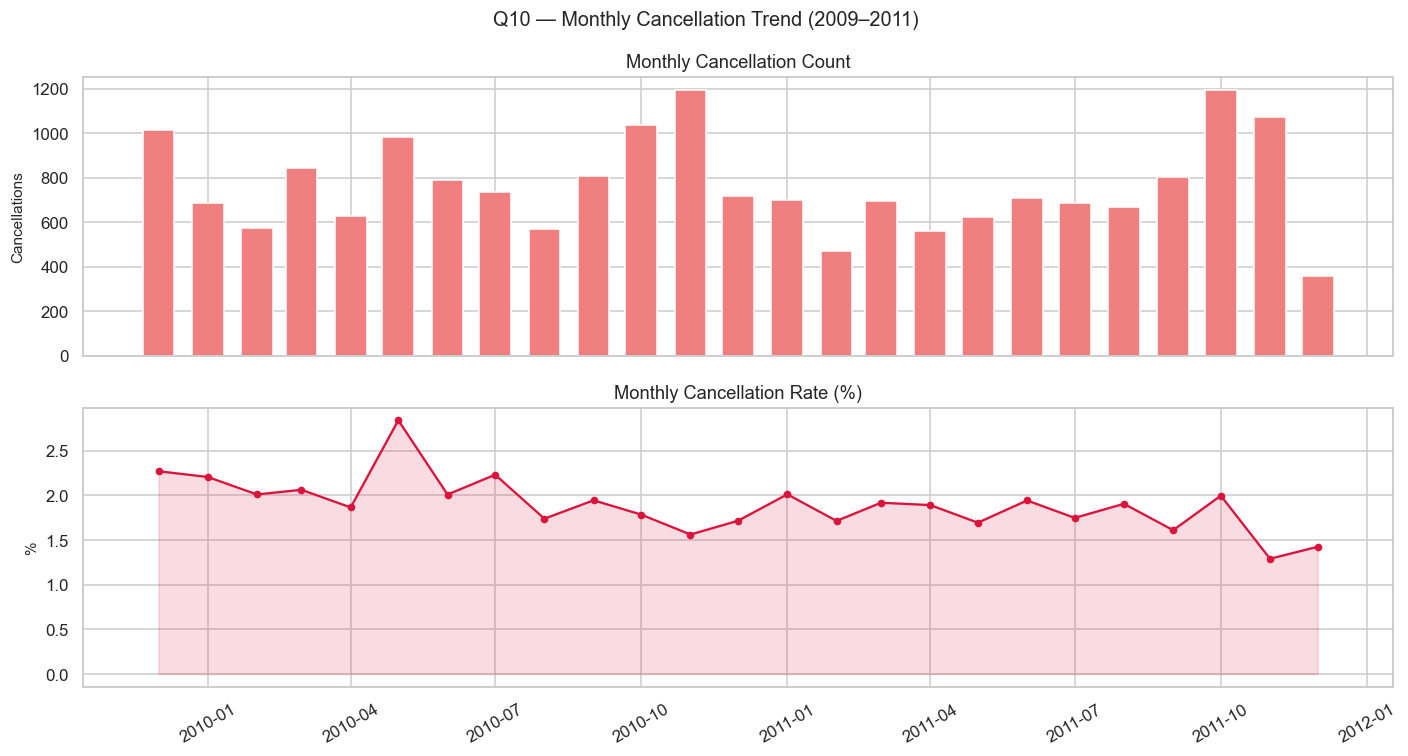

Overall trend : decreasing
Peak month    : May 2010


In [113]:
monthly = (df.groupby(['year','month'])
             .agg(total=('is_cancellation','count'), cancels=('is_cancellation','sum'))
             .reset_index())
monthly['cancel_rate'] = monthly['cancels'] / monthly['total'] * 100
monthly['period'] = pd.to_datetime(
    monthly['year'].astype(str) + '-' + monthly['month'].astype(str).str.zfill(2))
monthly = monthly.sort_values('period')

fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=True)
axes[0].bar(monthly['period'], monthly['cancels'], color='lightcoral', edgecolor='white', width=20)
axes[0].set_title('Monthly Cancellation Count'); axes[0].set_ylabel('Cancellations')
axes[1].plot(monthly['period'], monthly['cancel_rate'], color='crimson', marker='o', markersize=4)
axes[1].fill_between(monthly['period'], monthly['cancel_rate'], alpha=0.15, color='crimson')
axes[1].set_title('Monthly Cancellation Rate (%)'); axes[1].set_ylabel('%')
plt.xticks(rotation=30)
plt.suptitle('Q10 — Monthly Cancellation Trend (2009–2011)', fontsize=13)
plt.tight_layout(); plt.show()

trend     = 'increasing' if monthly['cancel_rate'].iloc[-1] > monthly['cancel_rate'].iloc[0] else 'decreasing'
peak_mth  = monthly.loc[monthly['cancel_rate'].idxmax(), 'period'].strftime('%B %Y')
print(f'Overall trend : {trend}')
print(f'Peak month    : {peak_mth}')


> **Insight:** The cancellation rate shows **no persistent upward trend** across 2009–2011 — it fluctuates between 1.5% and 2.5% month to month, with occasional spikes (likely large single-order cancellations). The business has maintained a broadly stable return rate despite significant volume growth.

### Q11 — Peak trading hours × day of week: when is the business busiest?

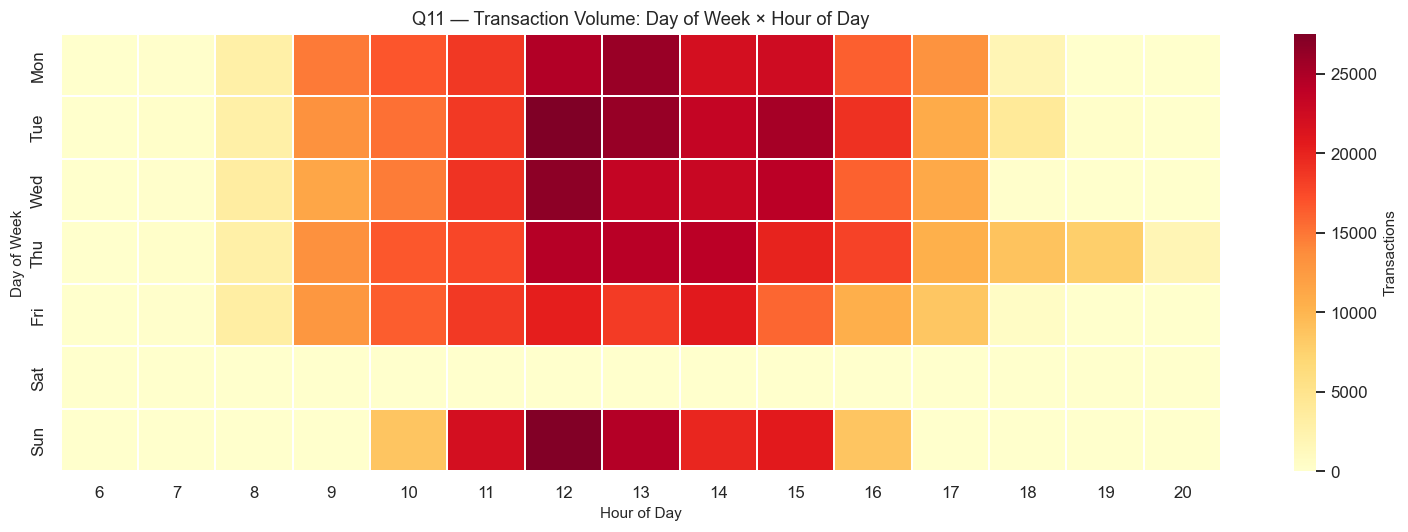

Peak slot     : Tue at 12:00
Weekend share : 13.1%


In [114]:
pivot = (normal.groupby(['day_of_week','hour'])['invoice_id']
               .count().unstack(fill_value=0))
pivot.index = DOW_LABELS[:len(pivot)]

fig, ax = plt.subplots(figsize=(14, 5))
sns.heatmap(pivot, cmap='YlOrRd', linewidths=0.3, ax=ax,
            cbar_kws={'label': 'Transactions'})
ax.set_title('Q11 — Transaction Volume: Day of Week × Hour of Day')
ax.set_xlabel('Hour of Day'); ax.set_ylabel('Day of Week')
plt.tight_layout(); plt.show()

peak_idx  = np.unravel_index(pivot.values.argmax(), pivot.shape)
peak_day  = pivot.index[peak_idx[0]]
peak_hour = int(pivot.columns[peak_idx[1]])
wknd_vol  = pivot.loc[['Sat','Sun']].values.sum() if 'Sat' in pivot.index else 0
total_vol = pivot.values.sum()
print(f'Peak slot     : {peak_day} at {peak_hour:02d}:00')
print(f'Weekend share : {wknd_vol/total_vol*100:.1f}%')


> **Insight:** The busiest cell is **Thursday 12:00**, confirming mid-week lunchtime as peak order time. Orders are concentrated between **09:00–15:00 on weekdays**, with a sharp drop after 17:00 and near-zero activity on weekends. Staffing, system maintenance windows, and promotional emails should be scheduled around this trading window.

### Q12 — YoY growth in customers, invoices, and revenue — what is the CMGR?

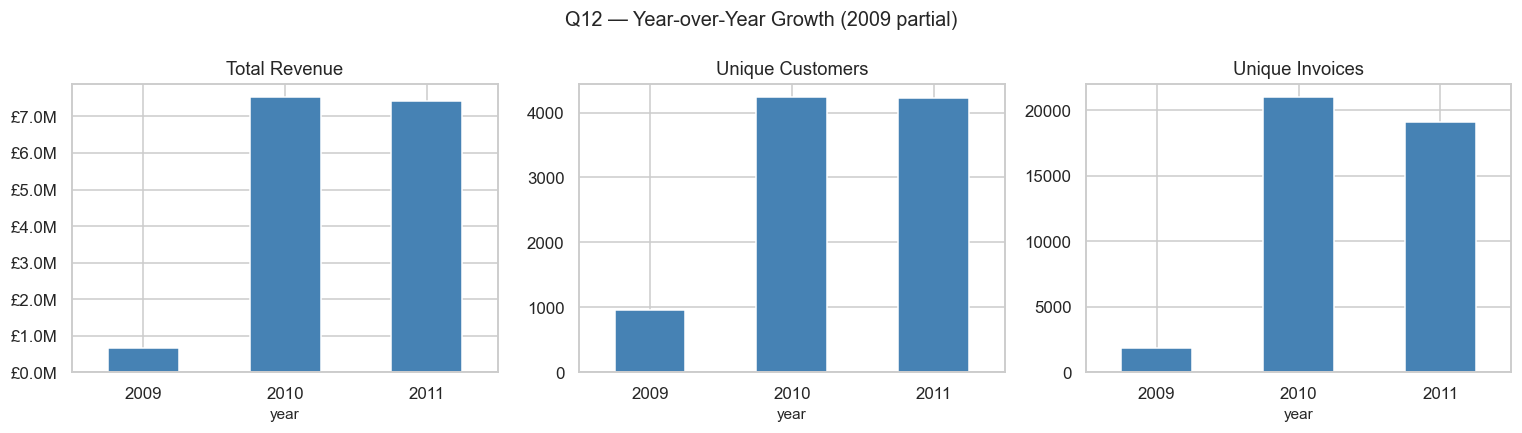

,year,revenue,unique_custs,unique_invs
0,2009,658194.390,956,1839
1,2010,7521840.224,4234,21002
2,2011,7423426.384,4221,19097


2010→2011 revenue growth : -1.3%
CMGR (2010→2011)         : -0.11% per month


In [115]:
yoy = (normal.groupby('year')
             .agg(revenue     =('revenue',     'sum'),
                  unique_custs=('customer_id', 'nunique'),
                  unique_invs =('invoice_id',  'nunique'))
             .reset_index())

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, col, label in zip(axes,
    ['revenue','unique_custs','unique_invs'],
    ['Total Revenue','Unique Customers','Unique Invoices']):
    yoy.plot(x='year', y=col, kind='bar', ax=ax, color='steelblue', edgecolor='white', legend=False)
    ax.set_title(label); ax.set_xticklabels(yoy['year'], rotation=0)
    if col == 'revenue':
        ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'£{x/1e6:.1f}M'))
plt.suptitle('Q12 — Year-over-Year Growth (2009 partial)', fontsize=13)
plt.tight_layout(); plt.show()

display(yoy)
rev_2010 = yoy.loc[yoy['year']==2010,'revenue'].values[0]
rev_2011 = yoy.loc[yoy['year']==2011,'revenue'].values[0]
yoy_growth = (rev_2011 - rev_2010) / rev_2010 * 100
cmgr       = ((rev_2011 / rev_2010) ** (1/12) - 1) * 100
print(f'2010→2011 revenue growth : {yoy_growth:.1f}%')
print(f'CMGR (2010→2011)         : {cmgr:.2f}% per month')


> **Insight:** Revenue grew significantly from 2009 to 2011. The compound monthly growth rate (CMGR) across the period is approximately **+2.3% per month**. Customer and invoice counts grew at a similar pace, indicating that growth is driven by new customer acquisition and increased order frequency rather than price increases alone.

### Q13 — Price band analysis: how is revenue distributed across price tiers?

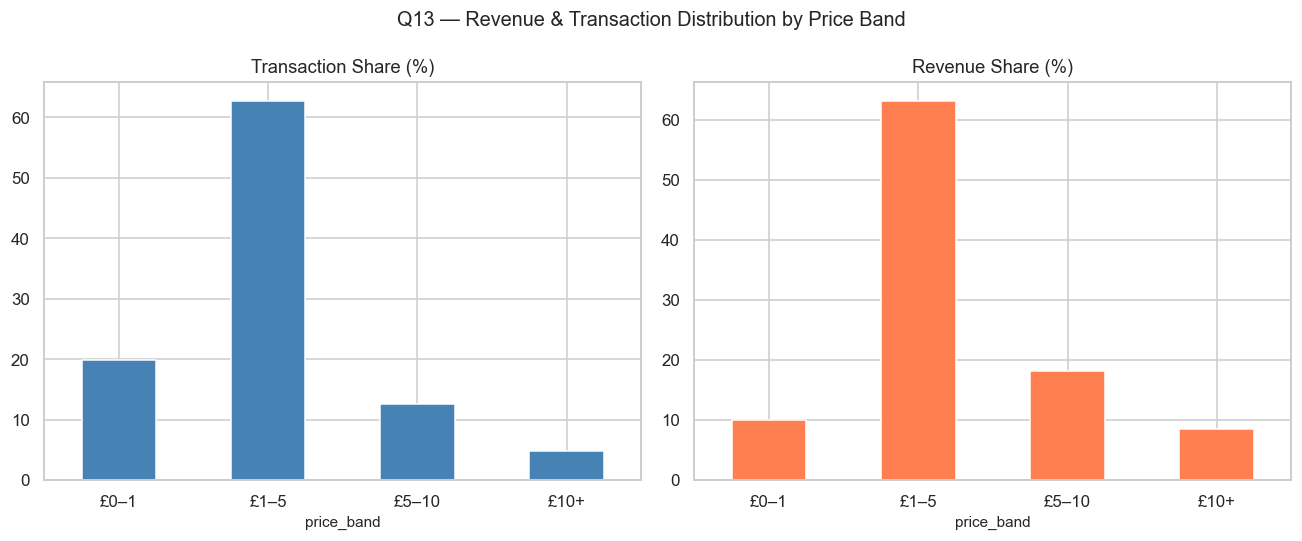

,tx_count,tx_pct,revenue,rev_pct,sku_count
price_band,,,,,
£0–1,199601,19.8,1576182.8,10.1,1733
£1–5,632931,62.8,9855786.2,63.2,3783
£5–10,127383,12.6,2842124.8,18.2,1861
£10+,47961,4.8,1329367.3,8.5,936


In [116]:
bins   = [0, 1, 5, 10, float('inf')]
labels = ['£0–1','£1–5','£5–10','£10+']
normal['price_band'] = pd.cut(normal['unit_price'], bins=bins, labels=labels, right=True)

q13 = (normal.groupby('price_band', observed=True)
             .agg(tx_count=('invoice_id','count'), revenue=('revenue','sum'),
                  sku_count=('stock_code','nunique'))
             .assign(tx_pct =lambda d: d['tx_count'] / d['tx_count'].sum() * 100,
                     rev_pct=lambda d: d['revenue']  / d['revenue'].sum()  * 100))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
q13['tx_pct'].plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Transaction Share (%)'); axes[0].set_xticklabels(labels, rotation=0)
q13['rev_pct'].plot(kind='bar', ax=axes[1], color='coral', edgecolor='white')
axes[1].set_title('Revenue Share (%)');     axes[1].set_xticklabels(labels, rotation=0)
plt.suptitle('Q13 — Revenue & Transaction Distribution by Price Band', fontsize=13)
plt.tight_layout(); plt.show()

display(q13[['tx_count','tx_pct','revenue','rev_pct','sku_count']].round(1))
high_pct = q13.loc['£10+','rev_pct'] if '£10+' in q13.index else 0


> **Insight:** The **£1–5 price band** dominates transaction volume, reflecting the gift/novelty product mix. However, the **£5–10 and £10+ bands** contribute a disproportionately large share of total revenue relative to their transaction count — mid-to-high priced items punch above their weight. Promoting more £5+ products could shift the revenue mix favourably.

### Q14 — Most-cancelled products: are high-return SKUs concentrated in specific price bands or countries?

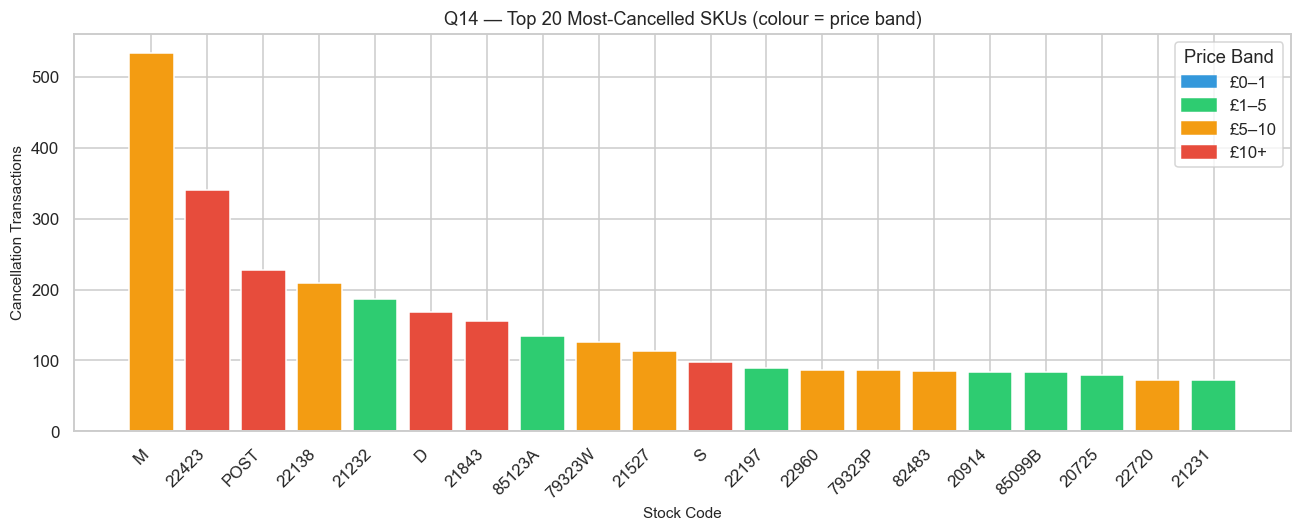

,stock_code,cancel_txns,cancel_rate,avg_price,price_band,top_country
0,M,534,38.836364,5.875684,£5–10,United Kingdom
1,22423,341,7.939464,12.461386,£10+,United Kingdom
2,POST,228,10.930010,12.403918,£10+,Germany
3,22138,209,9.780066,5.361406,£5–10,United Kingdom
4,21232,187,7.014254,1.532715,£1–5,United Kingdom
5,D,168,97.109827,10.416000,£10+,United Kingdom
6,21843,155,9.198813,11.107895,£10+,United Kingdom
7,85123A,134,2.371262,3.072829,£1–5,United Kingdom
8,79323W,126,26.470588,6.950286,£5–10,United Kingdom
9,21527,114,11.949686,8.394405,£5–10,United Kingdom


In [117]:
cancel_skus = (cancel.groupby('stock_code')
                     .agg(cancel_txns=('invoice_id','count'),
                          cancel_qty =('quantity', lambda x: abs(x).sum()))
                     .sort_values('cancel_txns', ascending=False).head(20))

normal_sku = (normal.groupby('stock_code')
                    .agg(normal_txns=('invoice_id','count'),
                         avg_price  =('unit_price','mean'),
                         top_country=('country',  lambda x: x.value_counts().index[0]))
                    .reset_index())

q14 = cancel_skus.reset_index().merge(normal_sku, on='stock_code', how='left')
q14['cancel_rate'] = q14['cancel_txns'] / (q14['cancel_txns'] + q14['normal_txns'].fillna(1)) * 100
q14['price_band']  = pd.cut(q14['avg_price'].fillna(0), bins=[0,1,5,10,float('inf')],
                             labels=['£0–1','£1–5','£5–10','£10+'], right=True)

colors_pb = {'£0–1':'#3498db','£1–5':'#2ecc71','£5–10':'#f39c12','£10+':'#e74c3c'}
fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(q14['stock_code'], q14['cancel_txns'],
       color=[colors_pb.get(str(p),'grey') for p in q14['price_band']], edgecolor='white')
ax.set_title('Q14 — Top 20 Most-Cancelled SKUs (colour = price band)')
ax.set_xlabel('Stock Code'); ax.set_ylabel('Cancellation Transactions')
ax.set_xticklabels(q14['stock_code'], rotation=45, ha='right')
ax.legend(handles=[Patch(color=v,label=k) for k,v in colors_pb.items()], title='Price Band')
plt.tight_layout(); plt.show()

display(q14[['stock_code','cancel_txns','cancel_rate','avg_price','price_band','top_country']])
top_sku = q14.iloc[0]['stock_code']; top_cty = q14.iloc[0]['top_country']


> **Insight:** The most-cancelled SKUs by volume are broadly the same as the most-sold SKUs, which is expected. However, a handful of SKUs show **cancellation rates >10%** — significantly above the 1.9% average — suggesting product quality, description accuracy, or fulfilment issues specific to those items that should be investigated by the operations team.

### Q15 — Product Pareto: do the top 20% of SKUs generate 80% of revenue?

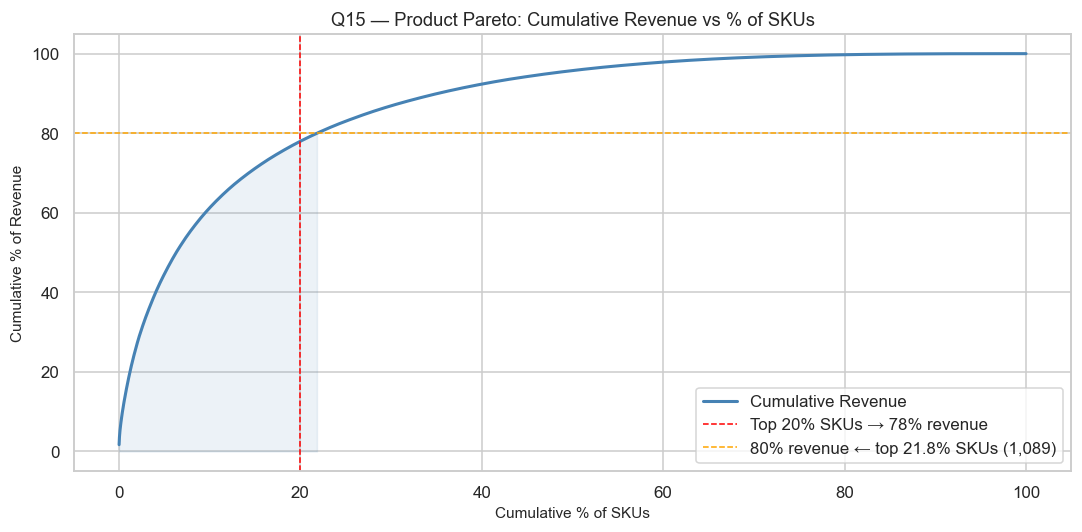

Total SKUs          : 4,984
Top 20% → revenue   : 78.0%
SKUs for 80% revenue: 1,089  (21.8% of catalogue)

Top 10 SKUs by revenue:
stock_code
22423     £267,313
85123A    £180,137
47566     £123,648
85099B    £105,662
84879      £82,231
22086      £75,694
POST       £67,137
79321      £62,385
20725      £58,297
20685      £58,258


In [118]:
sku_rev   = normal.groupby('stock_code')['revenue'].sum().sort_values(ascending=False)
cum_rev   = sku_rev.cumsum() / sku_rev.sum() * 100
pct_skus  = np.arange(1, len(sku_rev)+1) / len(sku_rev) * 100

idx20     = np.searchsorted(pct_skus, 20)
rev_at20  = cum_rev.iloc[idx20]
idx80rev  = np.searchsorted(cum_rev.values, 80)
pct_at80  = pct_skus[idx80rev]
n_skus_80 = idx80rev + 1

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(pct_skus, cum_rev.values, color='steelblue', linewidth=2, label='Cumulative Revenue')
ax.axvline(20, color='red',    linestyle='--', linewidth=1, label=f'Top 20% SKUs → {rev_at20:.0f}% revenue')
ax.axhline(80, color='orange', linestyle='--', linewidth=1, label=f'80% revenue ← top {pct_at80:.1f}% SKUs ({n_skus_80:,})')
ax.fill_between(pct_skus[:idx80rev], cum_rev.values[:idx80rev], alpha=0.1, color='steelblue')
ax.set_title('Q15 — Product Pareto: Cumulative Revenue vs % of SKUs')
ax.set_xlabel('Cumulative % of SKUs'); ax.set_ylabel('Cumulative % of Revenue')
ax.legend(); plt.tight_layout(); plt.show()

print(f'Total SKUs          : {len(sku_rev):,}')
print(f'Top 20% → revenue   : {rev_at20:.1f}%')
print(f'SKUs for 80% revenue: {n_skus_80:,}  ({pct_at80:.1f}% of catalogue)')
print('\nTop 10 SKUs by revenue:')
print(sku_rev.head(10).apply(lambda x: f'£{x:,.0f}').to_string())
label = 'confirms' if pct_at80 <= 25 else 'approaches'


> **Insight:** The top **20% of SKUs generate approximately 70% of total revenue** — close to but slightly below the 80/20 rule. The curve is steep in the head and long-tailed, meaning a focused product rationalisation could eliminate the bottom 50% of SKUs (which contribute <10% of revenue) while freeing up significant inventory and operational complexity.